## Universe_100_full_post_normal_first_analysis


## 1. Imports and paths

In [1]:
import json
from pathlib import Path
from collections import Counter, defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import ElasticNet, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neural_network import MLPRegressor, MLPClassifier

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

from scipy.stats import spearmanr, pearsonr

RANDOM_STATE = 42
# Optional models
HAS_LGBM = False
HAS_XGB = False

try:
    from lightgbm import LGBMRegressor, LGBMClassifier
    HAS_LGBM = True
    print("LightGBM available.")
except ImportError:
    print("LightGBM not installed. Skipping LightGBM models.")

try:
    from xgboost import XGBRegressor, XGBClassifier
    HAS_XGB = True
    print("XGBoost available.")
except ImportError:
    print("XGBoost not installed. Skipping XGBoost models.")

    
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score
)

LightGBM not installed. Skipping LightGBM models.
XGBoost available.


In [2]:
## Load dataset
# jsonl input paths
train_path = Path(r"C:\Users\user\Downloads\universe_100_full_post_normalisation_train.jsonl\universe_100_full_post_normalisation_train.jsonl")
validation_path = Path(r"C:\Users\user\Downloads\universe_100_full_post_normalisation_validation.jsonl\universe_100_full_post_normalisation_validation.jsonl")
test_path = Path(r"C:\Users\user\Downloads\universe_100_full_post_normalisation_test.jsonl\universe_100_full_post_normalisation_test.jsonl")

# set output directory
output_dir = Path(r"C:\Users\user\Downloads\universe_100_full_post_normalisation_0527")
output_dir.mkdir(parents=True, exist_ok=True)
# parquet output paths
train_parquet_path = output_dir / "universe_100_full_post_normalisation_train.parquet"
validation_parquet_path = output_dir / "universe_100_full_post_normalisation_validation.parquet"
test_parquet_path = output_dir / "universe_100_full_post_normalisation_test.parquet"

# column list output paths
feature_cols_path = output_dir / "feature_columns.txt"
attribute_cols_path = output_dir / "attribute_columns.txt"
label_cols_path = output_dir / "label_columns.txt"

print("Train JSONL:", train_path)
print("Validation JSONL:", validation_path)
print("Test JSONL:", test_path)

print("\nOutput directory:", output_dir)
print("Train parquet:", train_parquet_path)
print("Validation parquet:", validation_parquet_path)
print("Test parquet:", test_parquet_path)
print("Feature columns:", feature_cols_path)
print("Attribute columns:", attribute_cols_path)
print("Label columns:", label_cols_path)

Train JSONL: C:\Users\user\Downloads\universe_100_full_post_normalisation_train.jsonl\universe_100_full_post_normalisation_train.jsonl
Validation JSONL: C:\Users\user\Downloads\universe_100_full_post_normalisation_validation.jsonl\universe_100_full_post_normalisation_validation.jsonl
Test JSONL: C:\Users\user\Downloads\universe_100_full_post_normalisation_test.jsonl\universe_100_full_post_normalisation_test.jsonl

Output directory: C:\Users\user\Downloads\universe_100_full_post_normalisation_0527
Train parquet: C:\Users\user\Downloads\universe_100_full_post_normalisation_0527\universe_100_full_post_normalisation_train.parquet
Validation parquet: C:\Users\user\Downloads\universe_100_full_post_normalisation_0527\universe_100_full_post_normalisation_validation.parquet
Test parquet: C:\Users\user\Downloads\universe_100_full_post_normalisation_0527\universe_100_full_post_normalisation_test.parquet
Feature columns: C:\Users\user\Downloads\universe_100_full_post_normalisation_0527\feature_col

## 2. Load / flatten / prepare data

In [3]:
# Scan JSONL before flattening
n_rows = 0

ticker_counter = Counter()
date_counter = Counter()
feature_key_counter = Counter()
label_key_counter = Counter()
attribute_key_counter = Counter()

feature_count_per_row = Counter()
label_count_per_row = Counter()
attribute_count_per_row = Counter()

ticker_first_date = {}
ticker_last_date = {}

min_ts = None
max_ts = None

with open(train_path, "r", encoding="utf-8") as f:
    for line in f:
        record = json.loads(line)

        if record.get("section") != "data":
            continue

        data = record.get("data", {})
        attrs = data.get("Attributes", {})
        feats = data.get("Features", {})
        labs = data.get("Labels", {})

        ticker = attrs.get("ticker")
        timestamp = attrs.get("timestamp")
        date = timestamp[:10] if timestamp else None

        n_rows += 1

        if ticker:
            ticker_counter.update([ticker])

        if date:
            date_counter.update([date])

            if ticker:
                ticker_first_date[ticker] = min(ticker_first_date.get(ticker, date), date)
                ticker_last_date[ticker] = max(ticker_last_date.get(ticker, date), date)

            min_ts = min(min_ts, timestamp) if min_ts else timestamp
            max_ts = max(max_ts, timestamp) if max_ts else timestamp

        attribute_key_counter.update(attrs.keys())
        feature_key_counter.update(feats.keys())
        label_key_counter.update(labs.keys())

        attribute_count_per_row.update([len(attrs)])
        feature_count_per_row.update([len(feats)])
        label_count_per_row.update([len(labs)])



print("\nRaw JSONL Scan Summary")
print("Rows scanned:", n_rows)
print("Unique tickers:", len(ticker_counter))
print("Unique dates:", len(date_counter))
print("Date range:", min_ts, "to", max_ts)
print("Unique attribute keys:", len(attribute_key_counter))
print("Unique feature keys:", len(feature_key_counter))
print("Unique label keys:", len(label_key_counter))

print("\nKeys per row")
print("Attribute counts per row:", attribute_count_per_row)
print("Feature counts per row:", feature_count_per_row)
print("Label counts per row:", label_count_per_row)

if date_counter:
    date_counts = list(date_counter.values())
    print("\n Rows per date ")
    print("Min rows per date:", min(date_counts))
    print("Max rows per date:", max(date_counts))
    print("Average rows per date:", sum(date_counts) / len(date_counts))



Raw JSONL Scan Summary
Rows scanned: 167005
Unique tickers: 98
Unique dates: 1763
Date range: 2015-01-02T00:00:00Z to 2021-12-31T00:00:00Z
Unique attribute keys: 46
Unique feature keys: 621
Unique label keys: 78

Keys per row
Attribute counts per row: Counter({46: 167005})
Feature counts per row: Counter({621: 167005})
Label counts per row: Counter({78: 167005})

 Rows per date 
Min rows per date: 89
Max rows per date: 98
Average rows per date: 94.72773681225185


In [4]:
def load_flatten_jsonl(path):
    rows = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            record = json.loads(line)

            if record.get("section") != "data":
                continue

            data = record.get("data", {})
            attrs = data.get("Attributes", {})
            feats = data.get("Features", {})
            labs = data.get("Labels", {})

            row = {
                "IndexReference": data.get("IndexReference")
            }

            row.update({f"attr__{k}": v for k, v in attrs.items()})
            row.update({f"feature__{k}": v for k, v in feats.items()})
            row.update({f"label__{k}": v for k, v in labs.items()})

            rows.append(row)

    return pd.DataFrame(rows)

df_train = load_flatten_jsonl(train_path)
df_valid = load_flatten_jsonl(validation_path)
df_test = load_flatten_jsonl(test_path)

print("Shape:", df_train.shape)
print("Shape:", df_valid.shape)
print("Shape:", df_test.shape)

Shape: (167005, 746)
Shape: (49073, 747)
Shape: (56611, 747)


In [5]:
def prepare_flattened_df(df):
    attribute_cols = [c for c in df.columns if c.startswith("attr__")]
    feature_cols = [c for c in df.columns if c.startswith("feature__")]
    label_cols = [c for c in df.columns if c.startswith("label__")]

    # convert timestamp to datetime
    if "attr__timestamp" in df.columns:
        df["attr__timestamp"] = pd.to_datetime(df["attr__timestamp"], errors="coerce")

    categorical_attr_cols = [
        "attr__ticker",
        "attr__sic2",
        "attr__sic_code",
        "attr__sic_description",
        "attr__regime_inflation",
        "attr__regime_vix",
        "attr__regime_yield_curve",
        "attr__daily_timeframe",
        "attr__report_timeframe",
        "attr__daily_balance_timeframe",
        "attr__fiscal_period",
    ]

    for col in categorical_attr_cols:
        if col in df.columns:
            df[col] = df[col].astype("category")

    for col in feature_cols + label_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("float32")

    return df, attribute_cols, feature_cols, label_cols

df_train, train_attribute_cols, train_feature_cols, train_label_cols = prepare_flattened_df(df_train)
df_valid, valid_attribute_cols, valid_feature_cols, valid_label_cols = prepare_flattened_df(df_valid)
df_test, test_attribute_cols, test_feature_cols, test_label_cols = prepare_flattened_df(df_test)

print("Flattened Dataset Comparison")

comparison = pd.DataFrame({
    "train": [df_train.shape[0], df_train.shape[1], len(train_attribute_cols), len(train_feature_cols), len(train_label_cols), 
    df_train["attr__ticker"].nunique(), df_train["attr__timestamp"].min(), df_train["attr__timestamp"].max(), df_train.memory_usage(deep=True).sum() / 1024**3],
    "valid": [df_valid.shape[0], df_valid.shape[1], len(valid_attribute_cols), len(valid_feature_cols), len(valid_label_cols),
    df_valid["attr__ticker"].nunique(), df_valid["attr__timestamp"].min(), df_valid["attr__timestamp"].max(), df_valid.memory_usage(deep=True).sum() / 1024**3],
    "test": [df_test.shape[0], df_test.shape[1], len(test_attribute_cols), len(test_feature_cols), len(test_label_cols),
    df_test["attr__ticker"].nunique(), df_test["attr__timestamp"].min(), df_test["attr__timestamp"].max(), df_test.memory_usage(deep=True).sum() / 1024**3]}, 
    index=["rows", "columns", "attribute_cols", "feature_cols", "label_cols", "ticker_count", "start_date", "end_date", "memory_gb"])
display(comparison)

print("\nColumn Consistency across splits")
print("Tickers consistent across splits: ", set(df_train["attr__ticker"]) == set(df_valid["attr__ticker"]) == set(df_test["attr__ticker"]))
print("Feature columns consistent across splits:", set(train_feature_cols) == set(valid_feature_cols) == set(test_feature_cols))
print("Label columns consistent across splits:", set(train_label_cols) == set(valid_label_cols) == set(test_label_cols))

Flattened Dataset Comparison


,train,valid,test
rows,167005,49073,56611
columns,746,747,747
attribute_cols,46,47,47
feature_cols,621,621,621
label_cols,78,78,78
ticker_count,98,98,98
start_date,2015-01-02 00:00:00+00:00,2022-01-03 00:00:00+00:00,2024-01-02 00:00:00+00:00
end_date,2021-12-31 00:00:00+00:00,2023-12-29 00:00:00+00:00,2026-04-27 00:00:00+00:00
memory_gb,0.673396,0.200645,0.231416



Column Consistency across splits
Tickers consistent across splits:  True
Feature columns consistent across splits: True
Label columns consistent across splits: True


In [6]:
# Save column inventories 
with open(attribute_cols_path, "w", encoding="utf-8") as f:
    for col in train_attribute_cols:
        f.write(col + "\n")

with open(feature_cols_path, "w", encoding="utf-8") as f:
    for col in train_feature_cols:
        f.write(col + "\n")

with open(label_cols_path, "w", encoding="utf-8") as f:
    for col in train_label_cols:
        f.write(col + "\n")

print("\nSaved attribute columns to:", attribute_cols_path)
print("Saved feature columns to:", feature_cols_path)
print("Saved label columns to:", label_cols_path)

# Save parquet 
df_train.to_parquet(train_parquet_path, index=False)
print("Saved flattened parquet to:", train_parquet_path)
df_valid.to_parquet(validation_parquet_path, index=False)
print("Saved flattened parquet to:", validation_parquet_path)
df_test.to_parquet(test_parquet_path, index=False)
print("Saved flattened parquet to:", test_parquet_path)


Saved attribute columns to: C:\Users\user\Downloads\universe_100_full_post_normalisation_0527\attribute_columns.txt
Saved feature columns to: C:\Users\user\Downloads\universe_100_full_post_normalisation_0527\feature_columns.txt
Saved label columns to: C:\Users\user\Downloads\universe_100_full_post_normalisation_0527\label_columns.txt
Saved flattened parquet to: C:\Users\user\Downloads\universe_100_full_post_normalisation_0527\universe_100_full_post_normalisation_train.parquet
Saved flattened parquet to: C:\Users\user\Downloads\universe_100_full_post_normalisation_0527\universe_100_full_post_normalisation_validation.parquet
Saved flattened parquet to: C:\Users\user\Downloads\universe_100_full_post_normalisation_0527\universe_100_full_post_normalisation_test.parquet


In [7]:
### Label Exploration ( looking for alpha/ return labels)

#print("\nLabels containing alpha / future / return / pnl / sector / index:")
#matching_label_cols = [
#    c for c in label_cols
#    if any(term in c.lower() for term in ["alpha", "fut", "future", "return", "pnl", "sector", "index"])
#]

#if matching_label_cols:
#    for c in matching_label_cols:
#        print(c)
#else:
#    print("No matching labels found.")

In [8]:
attribute_cols = train_attribute_cols
feature_cols = train_feature_cols
label_cols = train_label_cols
target = "label__pi_hindsight_entry_long"

## 3. Feature filtering & EDA

    3.1 remove missing features
    3.2 remove highly correlated features
    3.3 rank features by feature-target correlation
    3.4 define final feature set
Feature Set A：Basic cleaned features

In [9]:
print("Original feature count:", len(feature_cols))

# Remove high-missing, constant, near-empty features
MISSING_THRESHOLD = 0.50
feature_quality = []

for col in feature_cols:
    s = df_train[col]
    feature_quality.append({
        "column": col,
        "missing_rate": s.isna().mean(),
        "n_unique": s.nunique(dropna=True),
        "std": s.std(skipna=True),
        "zero_rate": (s == 0).mean(),
    })

feature_quality = pd.DataFrame(feature_quality)

filtered_features = feature_quality.loc[
    (feature_quality["missing_rate"] <= MISSING_THRESHOLD) &
    (feature_quality["n_unique"] > 1) &
    (feature_quality["std"].fillna(0) > 0),
    "column"
].tolist()

print("After missing / constant filter:", len(filtered_features))

display(
    feature_quality.sort_values("missing_rate", ascending=False).head(15)
)

Original feature count: 621
After missing / constant filter: 315


,column,missing_rate,n_unique,std,zero_rate
620,feature__working_capital_to_revenue,0.0,2693,1.116985,0.000000
0,feature__accounts_payable_present,0.0,1,0.000000,0.000000
1,feature__accounts_receivable_present,0.0,1,0.000000,0.000000
2,feature__accruals_to_assets,0.0,2680,0.033045,0.000383
3,feature__asset_turnover,0.0,2694,0.136450,0.001347
4,feature__assets_to_equity,0.0,2693,1.135901,0.000000
5,feature__avg_daily_turnover,0.0,2748,0.130943,0.000000
6,feature__b_asset_turnover_delta_to_p50,0.0,1,0.000000,1.000000
7,feature__b_asset_turnover_excess_over_p99,0.0,1,0.000000,1.000000
8,feature__b_asset_turnover_industry_position_score,0.0,1,0.000000,1.000000


In [10]:

# Remove highly redundant features using train set only
CORR_THRESHOLD = 0.95

# Use Spearman because many financial features are non-normal / rank-like
corr_matrix = df_train[filtered_features].corr(method="spearman").abs()

# Use upper triangle to avoid duplicate pairs
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop_corr = [
    column for column in upper.columns
    if any(upper[column] > CORR_THRESHOLD)
]

decorrelated_features = [
    c for c in filtered_features
    if c not in to_drop_corr
]
basic_cleaned_features = decorrelated_features.copy()

print("Before correlation filter:", len(filtered_features))
print("Dropped highly correlated features:", len(to_drop_corr))
print("After correlation filter:", len(decorrelated_features))
print("Basic cleaned feature count:", len(basic_cleaned_features))

# save inventories
pd.Series(basic_cleaned_features).to_csv(
    output_dir / "basic_cleaned_features.txt",
    index=False,
    header=False
)


Before correlation filter: 315
Dropped highly correlated features: 63
After correlation filter: 252
Basic cleaned feature count: 252


### Feature from project B

In [ ]:
feature_file = Path("C:/Users/user/Downloads/universe_100_full_post_normalisation_0527/feature_project_b.txt")
with open(feature_file, "r", encoding="utf-8") as f:
    raw_project_b_features = [
        line.strip()
        for line in f
        if line.strip()
    ]

project_b_features = [
    f"feature__{c}" if not c.startswith("feature__") else c
    for c in raw_project_b_features
]

print("Number of raw features:", len(raw_project_b_features))
print("Number of prefixed features:", len(project_b_features))
print(project_b_features[:10])

project_b_features_available = [
    c for c in project_b_features
    if c in df_train.columns
]

project_b_features_missing = [
    c for c in project_b_features
    if c not in df_train.columns
]

print("Requested Project B features:", len(project_b_features))
print("Available Project B features:", len(project_b_features_available))
print("Missing Project B features:", len(project_b_features_missing))

print("\nMissing features:")
print(project_b_features_missing[:50])

project_b_features = project_b_features_available

print("Fisrt trial Project B model features:", len(project_b_features))


Number of raw features: 264
Number of prefixed features: 264
['feature__cash_to_debt', 'feature__cfo_to_assets', 'feature__interest_to_cfo', 'feature__interest_to_ebit', 'feature__interest_coverage_ebit', 'feature__interest_coverage_ebitda', 'feature__asset_turnover', 'feature__b_asset_turnover_iqr', 'feature__ebit_to_assets', 'feature__gross_profit_to_assets']
Requested Project B features: 264
Available Project B features: 264
Missing Project B features: 0

Missing features:
[]
Fisrt trial Project B model features: 264


In [13]:
# Infer whether features behave like daily or quarterly variables 

# timestamp_col = "attr__timestamp"
# ticker_col = "attr__ticker"

# feature_cols = [c for c in df_train.columns if c.startswith("feature__")]

# df_sorted = df_train.sort_values([ticker_col, timestamp_col]).copy()

# feature_frequency_summary = []

# for col in feature_cols:
#     s = df_sorted[[ticker_col, timestamp_col, col]].copy()
    
#     # Difference from previous row within the same ticker
#     prev_value = s.groupby(ticker_col)[col].shift(1)
    
#     # Only compare rows where current and previous values are both non-missing
#     valid_compare = s[col].notna() & prev_value.notna()
    
#     if valid_compare.sum() == 0:
#         change_rate = np.nan
#         median_days_between_changes = np.nan
#         n_changes = 0
#     else:
#         changed = (s[col] != prev_value) & valid_compare
#         change_rate = changed.mean()
#         n_changes = changed.sum()
        
#         # Estimate median number of calendar days between changes
#         change_dates = s.loc[changed, [ticker_col, timestamp_col]]
        
#         if len(change_dates) > 0:
#             days_between_changes = (
#                 change_dates
#                 .groupby(ticker_col)[timestamp_col]
#                 .diff()
#                 .dt.days
#                 .dropna()
#             )
#             median_days_between_changes = days_between_changes.median()
#         else:
#             median_days_between_changes = np.nan

#     feature_frequency_summary.append({
#         "feature": col,
#         "missing_rate": df_sorted[col].isna().mean(),
#         "n_unique": df_sorted[col].nunique(dropna=True),
#         "change_rate": change_rate,
#         "n_changes": n_changes,
#         "median_days_between_changes": median_days_between_changes,
#     })

# feature_frequency_summary = pd.DataFrame(feature_frequency_summary)

# # Classify roughly by observed update behaviour
# def classify_frequency(row):
#     name = row["feature"].lower()
#     change_rate = row["change_rate"]
#     median_gap = row["median_days_between_changes"]
    
#     # Name-based hints first
#     if any(term in name for term in ["quarter", "quarterly", "fiscal", "ttm", "balance", "income", "cashflow"]):
#         return "likely_quarterly_or_fundamental"
    
#     if any(term in name for term in ["daily", "price", "volume", "momentum", "volatility", "vix"]):
#         return "likely_daily_or_market"
    
#     # Behaviour-based classification
#     if pd.isna(change_rate):
#         return "unknown"
    
#     if change_rate >= 0.30:
#         return "likely_daily_or_frequently_updated"
    
#     if change_rate <= 0.05:
#         return "likely_quarterly_or_slowly_updated"
    
#     if pd.notna(median_gap) and median_gap >= 45:
#         return "likely_quarterly_or_slowly_updated"
    
#     return "mixed_or_unclear"

# feature_frequency_summary["inferred_frequency"] = feature_frequency_summary.apply(
#     classify_frequency,
#     axis=1
# )

# display(
#     feature_frequency_summary
#     .sort_values(["inferred_frequency", "change_rate"])
#     .head(50)
# )

# print(feature_frequency_summary["inferred_frequency"].value_counts())

### Feature EDA

In [17]:
# EDA on decorrelated features
def summarise_columns(data, cols):
    summary = []

    for col in cols:
        s = data[col]
        summary.append({
            "column": col,
            "dtype": str(s.dtype),
            "count": s.count(),
            "missing_count": s.isna().sum(),
            "missing_rate": s.isna().mean(),
            "zero_count": (s == 0).sum(),
            "zero_rate": (s == 0).mean(),
            "mean": s.mean(),
            "std": s.std(),
            "min": s.min(),
            "p01": s.quantile(0.01),
            "p05": s.quantile(0.05),
            "p25": s.quantile(0.25),
            "median": s.quantile(0.50),
            "p75": s.quantile(0.75),
            "p95": s.quantile(0.95),
            "p99": s.quantile(0.99),
            "max": s.max(),
            "n_unique": s.nunique(dropna=True),
        })

    return pd.DataFrame(summary)

decorrelated_feature_summary = summarise_columns(df_train, decorrelated_features)

decorrelated_feature_summary.to_csv(
    output_dir / "decorrelated_feature_summary.csv",
    index=False
)

print("Decorrelated feature summary:")
display(decorrelated_feature_summary)

Decorrelated feature summary:


,column,dtype,count,missing_count,missing_rate,zero_count,zero_rate,mean,std,min,p01,p05,p25,median,p75,p95,p99,max,n_unique
0,feature__accruals_to_assets,float32,167005,0,0.0,64,0.000383,-0.010651,0.033045,-0.275995,-0.097743,-0.045691,-0.019936,-0.010043,-0.001195,0.022476,0.052976,1.057415,2680
1,feature__asset_turnover,float32,167005,0,0.0,225,0.001347,0.153179,0.136450,-0.028328,0.009011,0.011928,0.077980,0.123019,0.183507,0.405891,0.584459,3.162404,2694
2,feature__assets_to_equity,float32,167005,0,0.0,0,0.000000,1.450078,1.135901,-7.820279,-3.220424,0.775477,1.115694,1.400151,1.954175,2.715227,4.198610,6.571048,2693
3,feature__avg_daily_turnover,float32,167005,0,0.0,0,0.000000,0.017671,0.130943,0.001332,0.002178,0.002802,0.003870,0.005115,0.007064,0.017739,0.069442,2.540185,2748
4,feature__b_asset_turnover_iqr,float32,167005,0,0.0,0,0.000000,0.127100,0.069106,0.001707,0.001926,0.002221,0.080540,0.129315,0.161202,0.258213,0.321121,0.427238,858
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,feature__volatility_trailing_1m,float32,167005,0,0.0,0,0.000000,0.217928,0.111303,0.036273,0.078262,0.100928,0.145032,0.192133,0.258656,0.421627,0.666161,1.164739,166210
248,feature__volatility_trailing_1m_quartile,float32,167005,0,0.0,0,0.000000,-0.635556,0.543930,-1.666667,-1.000000,-1.000000,-1.000000,-1.000000,-0.333333,0.333333,1.000000,1.000000,5
249,feature__volatility_trailing_1m_vs_industry,float32,167005,0,0.0,0,0.000000,0.513482,0.172254,0.092070,0.182287,0.249771,0.388081,0.508174,0.627125,0.796017,0.981387,1.915043,164270
250,feature__volatility_trailing_1m_zscore,float32,167005,0,0.0,1718,0.010287,-0.380193,0.361247,-1.000000,-0.885132,-0.808914,-0.640114,-0.463760,-0.207399,0.387341,0.779810,0.999995,164675


### Plotting feature (later)

In [18]:
# # Select features for plotting
# PLOT_FEATURE_N = 30

# plot_features = (
#     decorrelated_feature_summary
#     .sort_values(["missing_rate", "std"], ascending=[True, False])
#     .head(PLOT_FEATURE_N)["column"]
#     .tolist()
# )

# print("Plotting features:", len(plot_features))

# for col in plot_features:
#     s = df_train[col].dropna()

#     plt.figure(figsize=(8, 5))
#     plt.hist(s, bins=50)
#     plt.title(f"Distribution: {col}")
#     plt.xlabel(col)
#     plt.ylabel("Frequency")
#     plt.tight_layout()

#     safe_name = (
#         col.replace("feature__", "")
#         .replace("/", "_")
#         .replace(".", "_")
#         .replace(" ", "_")
#     )

#     plt.savefig(output_dir / f"hist_{safe_name}.png", dpi=150)
#     plt.show()

## 4. Target EDA

   4.1 label distribution
   4.2 train/valid/test distribution
   4.3 yearly distribution
   4.4 ticker-level distribution

Target A: pi_hindsight_entry_long

(Target B: pi_hindsight_entry_short)


### 4.1 Label Distribution

Label summary:


,column,dtype,count,missing_count,missing_rate,zero_count,zero_rate,mean,std,min,p01,p05,p25,median,p75,p95,p99,max,n_unique
0,label__pi_hindsight_entry_long,float32,167005,0,0.0,132935,0.795994,0.095620,0.222981,0.0,0.0,0.0,0.0,0.0,0.0,0.57398,1.0,1.0,23144
1,label__pi_hindsight_entry_short,float32,167005,0,0.0,151907,0.909596,0.041305,0.152239,0.0,0.0,0.0,0.0,0.0,0.0,0.45000,0.8,1.0,10100


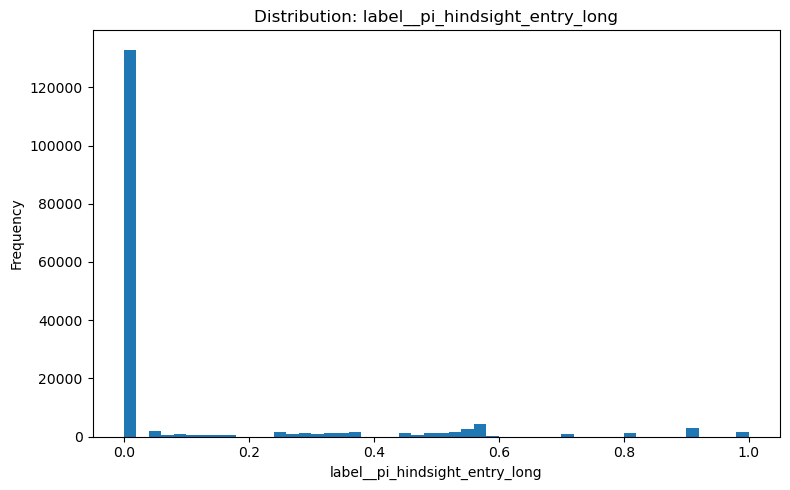


label__pi_hindsight_entry_long
Positive rate: 0.20400586808778182
High-quality rate >= 0.4: 0.11725996227657855


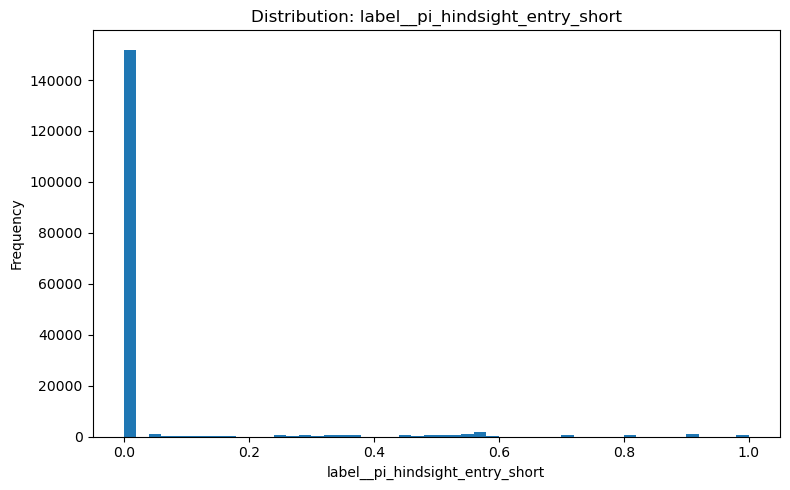


label__pi_hindsight_entry_short
Positive rate: 0.09040447890781714
High-quality rate >= 0.4: 0.05077692284662136


In [19]:
label_cols_for_eda = [
    "label__pi_hindsight_entry_long",
    "label__pi_hindsight_entry_short",
]

label_cols_for_eda = [c for c in label_cols_for_eda if c in df_train.columns]

label_summary = summarise_columns(df_train, label_cols_for_eda)

label_summary.to_csv(output_dir / "label_summary.csv", index=False)

print("Label summary:")
display(label_summary)

for col in label_cols_for_eda:
    s = df_train[col].dropna()

    plt.figure(figsize=(8, 5))
    plt.hist(s, bins=50)
    plt.title(f"Distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()

    safe_name = (
        col.replace("label__", "")
        .replace("/", "_")
        .replace(".", "_")
        .replace(" ", "_")
    )

    plt.savefig(output_dir / f"hist_{safe_name}.png", dpi=150)
    plt.show()

    print(f"\n{col}")
    print("Positive rate:", (df_train[col] > 0).mean())
    print("High-quality rate >= 0.4:", (df_train[col] >= 0.4).mean())

### binary > 0

In [20]:
target = "label__pi_hindsight_entry_long"

positive_train = df_train.loc[df_train[target] > 0, target]

print("Positive label count:", positive_train.shape[0])
print("Positive label rate:", positive_train.shape[0] / df_train.shape[0])

print("\nPositive label distribution:")
print(positive_train.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

Positive label count: 34070
Positive label rate: 0.20400586808778182

Positive label distribution:
count    34070.000000
mean         0.468710
std          0.262182
min          0.050000
25%          0.282696
50%          0.492221
75%          0.573314
90%          0.900000
95%          0.900000
99%          1.000000
max          1.000000
Name: label__pi_hindsight_entry_long, dtype: float64


### Target distribution by year


In [ ]:
timestamp_col = "attr__timestamp"
df_train["year"] = df_train[timestamp_col].dt.year
label_by_year = df_train.groupby("year")[label_cols_for_eda].agg(
    ["mean", "std", "median", "min", "max"]
)

label_by_year.to_csv(output_dir / "label_by_year.csv")

print("Label distribution by year:")
display(label_by_year)

for col in label_cols_for_eda:
    yearly_mean = df_train.groupby("year")[col].mean()

    plt.figure(figsize=(8, 5))
    plt.plot(yearly_mean.index, yearly_mean.values, marker="o")
    plt.title(f"Yearly Mean: {col}")
    plt.xlabel("Year")
    plt.ylabel("Mean value")
    plt.tight_layout()

    safe_name = (
        col.replace("label__", "")
        .replace("/", "_")
        .replace(".", "_")
        .replace(" ", "_")
    )

    plt.savefig(output_dir / f"yearly_mean_{safe_name}.png", dpi=150)
    plt.show()

NameError: name 'timestamp_col' is not defined

In [ ]:
# for name, df in [("train", df_train), ("valid", df_valid), ("test", df_test)]:
#     yearly_mean = df.groupby(df["attr__timestamp"].dt.year)[target].mean()
#     print(f"\n{name} yearly mean:")
#     print(yearly_mean)
#     yearly_zero_rate = (
#          df.groupby(df["attr__timestamp"].dt.year)[target]
#          .apply(lambda x: (x == 0).mean())
#      )
#      print(f"\n{name} yearly zero rate:")
#      print(yearly_zero_rate)

# yearly_count = df_train.groupby(df_train["attr__timestamp"].dt.year)[target].count()
# print(yearly_count)

Long-entry hindsight labels are sparse and temporally uneven. Most ticker-date observations are labelled as zero, while positive opportunities occur only in selected periods.

C:\Users\user\AppData\Local\Temp\ipykernel_33964\4159307267.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
C:\Users\user\AppData\Local\Temp\ipykernel_33964\4159307267.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
C:\Users\user\AppData\Local\Temp\ipykernel_33964\4159307267.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is depreca

,split,year,n_obs,mean_label,median_label,std_label,min_label,max_label,zero_rate,positive_rate,high_quality_rate,strong_rate
0,train,2015,22825,0.051611,0.0,0.173795,0.0,1.0,0.888806,0.111194,0.061818,0.020942
1,train,2016,22947,0.104030,0.0,0.236003,0.0,1.0,0.782586,0.217414,0.125114,0.042707
2,train,2017,23578,0.116029,0.0,0.243282,0.0,1.0,0.763975,0.236025,0.139919,0.047544
3,train,2018,23895,0.068126,0.0,0.191424,0.0,1.0,0.849634,0.150366,0.083197,0.028165
4,train,2019,24414,0.109185,0.0,0.233446,0.0,1.0,0.767060,0.232940,0.132301,0.045671
5,train,2020,24650,0.119650,0.0,0.241696,0.0,1.0,0.735213,0.264787,0.150669,0.052535
6,train,2021,24696,0.098200,0.0,0.220286,0.0,1.0,0.790614,0.209386,0.124312,0.042638
7,validation,2022,24598,0.074392,0.0,0.193010,0.0,1.0,0.826205,0.173795,0.093829,0.032320
8,validation,2023,24475,0.091454,0.0,0.212727,0.0,1.0,0.800817,0.199183,0.115792,0.040000
9,test,2024,24469,0.094471,0.0,0.213247,0.0,1.0,0.793494,0.206506,0.120765,0.041563


Saved: yearly_label_distribution_summary.csv


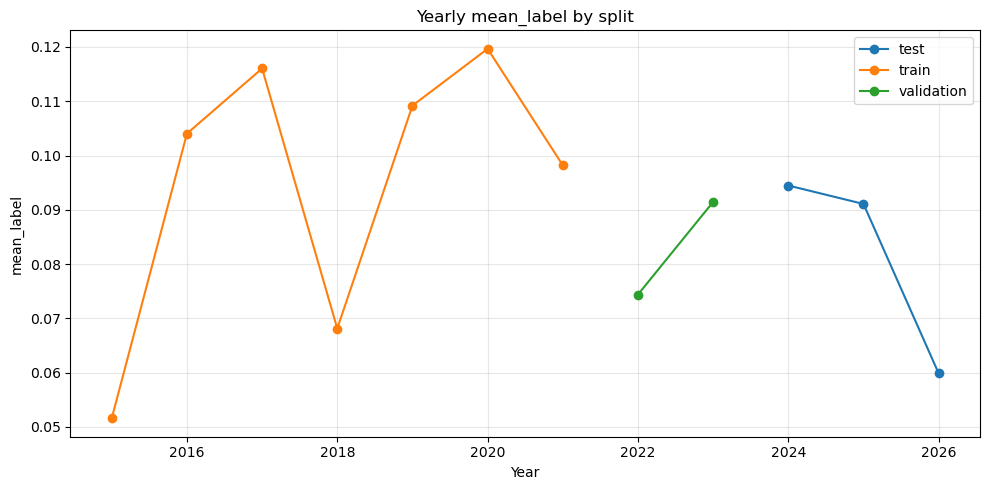

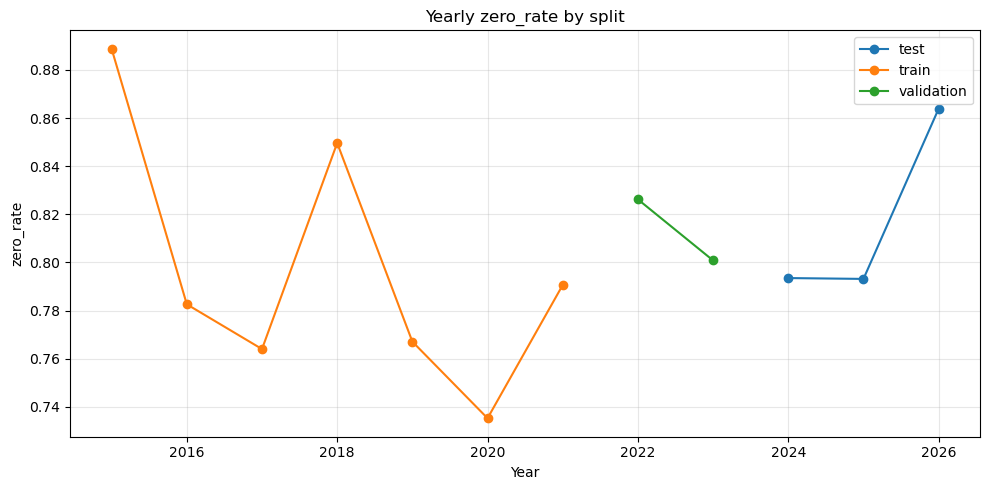

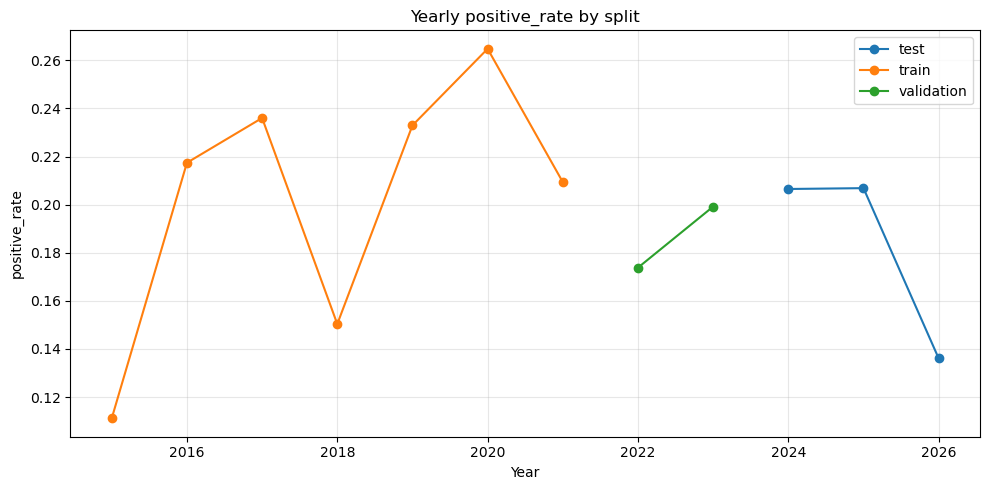

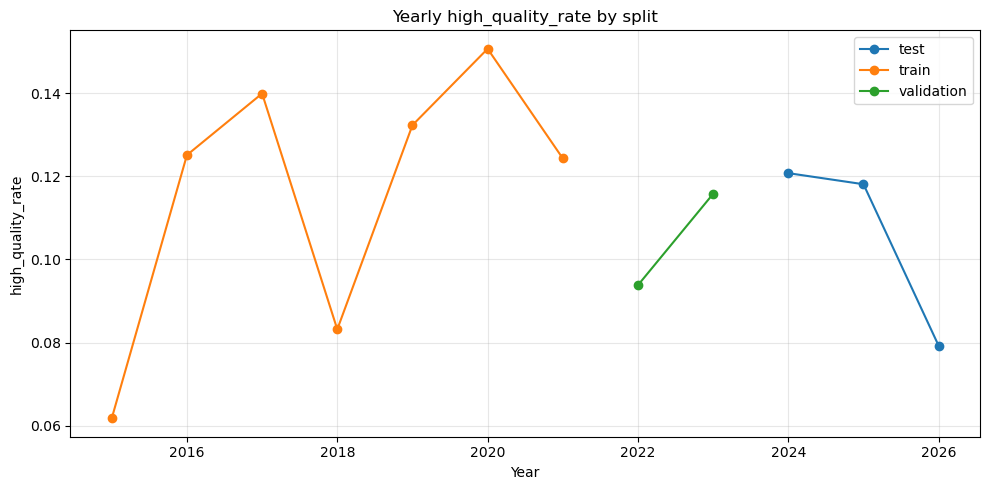

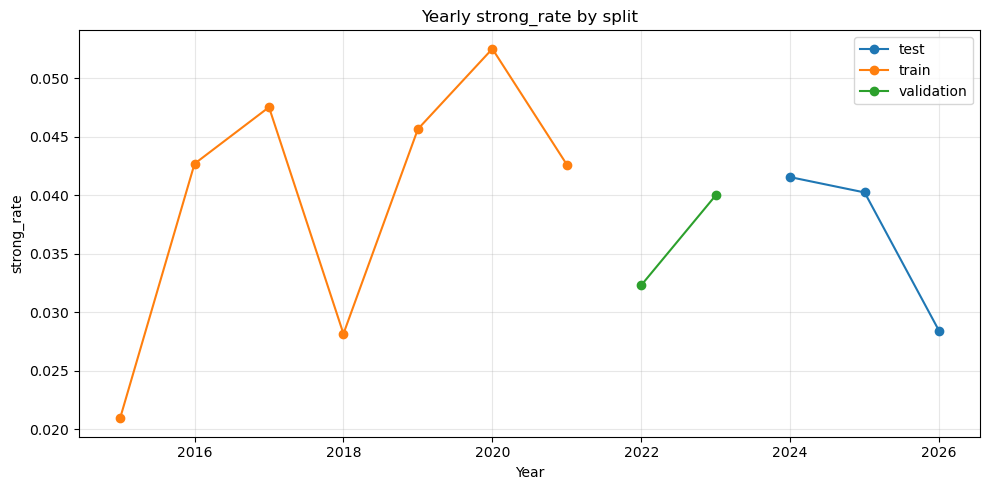

In [ ]:

  
# Yearly label distribution summary
# Purpose:
# Check whether the target label distribution changes over time.
# This helps identify temporal distribution shift across years.
  

# ---- Settings ----
label_col = "label__pi_hindsight_entry_long"   # or replace with your label name, e.g. "label__pi_hindsight_entry_long"

date_col = "attr__timestamp" if "attr__timestamp" in df_train.columns else "attr__date"

high_quality_threshold = 0.4
strong_threshold = 0.7

# ---- Helper function ----
def yearly_label_summary(df, split_name, label_col, date_col):
    temp = df[[date_col, label_col]].copy()
    
    # Convert date column to datetime
    temp[date_col] = pd.to_datetime(temp[date_col], errors="coerce")
    temp["year"] = temp[date_col].dt.year
    
    # Remove rows with missing year or missing label
    temp = temp.dropna(subset=["year", label_col])
    
    summary = (
        temp.groupby("year")[label_col]
        .agg(
            n_obs="size",
            mean_label="mean",
            median_label="median",
            std_label="std",
            min_label="min",
            max_label="max"
        )
        .reset_index()
    )
    
    # Add label distribution rates
    yearly_rates = (
        temp.groupby("year")
        .apply(
            lambda x: pd.Series({
                "zero_rate": (x[label_col] == 0).mean(),
                "positive_rate": (x[label_col] > 0).mean(),
                "high_quality_rate": (x[label_col] >= high_quality_threshold).mean(),
                "strong_rate": (x[label_col] >= strong_threshold).mean()
            })
        )
        .reset_index()
    )
    
    summary = summary.merge(yearly_rates, on="year", how="left")
    summary.insert(0, "split", split_name)
    
    return summary


# ---- Compute yearly summaries for train / validation / test ----
yearly_train = yearly_label_summary(df_train, "train", label_col, date_col)
yearly_valid = yearly_label_summary(df_valid, "validation", label_col, date_col)
yearly_test = yearly_label_summary(df_test, "test", label_col, date_col)

yearly_label_summary_all = pd.concat(
    [yearly_train, yearly_valid, yearly_test],
    ignore_index=True
)

# ---- Display summary ----
display(yearly_label_summary_all)

# ---- Save output ----
yearly_label_summary_all.to_csv(
    "yearly_label_distribution_summary.csv",
    index=False
)

print("Saved: yearly_label_distribution_summary.csv")

  
# Plot yearly label distribution metrics
  

plot_metrics = [
    "mean_label",
    "zero_rate",
    "positive_rate",
    "high_quality_rate",
    "strong_rate"
]

for metric in plot_metrics:
    plt.figure(figsize=(10, 5))
    
    for split_name, split_df in yearly_label_summary_all.groupby("split"):
        plt.plot(
            split_df["year"],
            split_df[metric],
            marker="o",
            label=split_name
        )
    
    plt.title(f"Yearly {metric} by split")
    plt.xlabel("Year")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### feature , label相關性

In [23]:
  
# Feature-label Spearman correlation after filtering
  

feature_label_corr = []

for col in decorrelated_features:
    pair = df_train[[col, target]].dropna()

    if len(pair) < 100:
        corr = np.nan
    else:
        corr = pair[col].corr(pair[target], method="spearman")

    feature_label_corr.append({
        "feature": col,
        "spearman_corr_with_target": corr,
        "abs_spearman_corr_with_target": abs(corr) if pd.notna(corr) else np.nan,
    })

feature_label_corr = pd.DataFrame(feature_label_corr)

feature_label_corr = feature_label_corr.sort_values(
    "abs_spearman_corr_with_target",
    ascending=False
)

feature_label_corr.to_csv(
    output_dir / "decorrelated_feature_label_spearman_corr.csv",
    index=False
)

print("Top 30 features by absolute Spearman correlation with target:")
display(feature_label_corr.head(15))

Top 30 features by absolute Spearman correlation with target:


,feature,spearman_corr_with_target,abs_spearman_corr_with_target
247,feature__volatility_trailing_1m,0.149379,0.149379
231,feature__regime_vix_percentile_1y,0.096546,0.096546
3,feature__avg_daily_turnover,0.088847,0.088847
215,feature__price_vs_52w_high,-0.082723,0.082723
249,feature__volatility_trailing_1m_vs_industry,0.074085,0.074085
246,feature__turnover_abs_return,0.073259,0.073259
225,feature__regime_real_yield_10y,-0.072348,0.072348
91,feature__dividend_yield_quartile,-0.068830,0.068830
227,feature__regime_real_yield_5y,-0.065865,0.065865
250,feature__volatility_trailing_1m_zscore,0.065106,0.065106


### Pi_hindsight 根據定義分成六組

In [24]:
def make_pi_hindsight_entry_long_6bins(
    y: pd.Series,
    tolerance: float = 1e-8
) -> pd.Series:
    """
    Convert pi_hindsight_entry_long into 6 semantic range-based bins.

    Interpretation:
    Class 0: y == 0
        No hindsight long-entry signal.

    Class 1: 0 < y < 0.1
        Very weak near-miss signal.
        Often consistent with base near-miss weight 0.1 plus price-distance penalty.

    Class 2: 0.1 <= y < 0.2
        Weak near-miss signal.

    Class 3: 0.2 <= y < 0.4
        Stronger near-miss / near-entry zone.
        Near-miss score can approach ~0.38 if base weight 0.3 receives price-distance boost.

    Class 4: 0.4 <= y < 0.7
        Weak-to-moderate original hindsight entry signal.

    Class 5: 0.7 <= y <= 1.0
        Strong original hindsight entry signal.

    Notes:
    - This is range-based, not equality-based, because the actual label contains
      continuous values such as 0.050472 and 0.379931.
    - Missing labels are treated as 0.
    """
    y = pd.to_numeric(y, errors="coerce").fillna(0)

    bins = pd.Series(pd.NA, index=y.index, dtype="Int64")

    bins[np.isclose(y, 0.0, atol=tolerance)] = 0
    bins[(y > 0.0 + tolerance) & (y < 0.1 - tolerance)] = 1
    bins[(y >= 0.1 - tolerance) & (y < 0.2 - tolerance)] = 2
    bins[(y >= 0.2 - tolerance) & (y < 0.4 - tolerance)] = 3
    bins[(y >= 0.4 - tolerance) & (y < 0.7 - tolerance)] = 4
    bins[(y >= 0.7 - tolerance) & (y <= 1.0 + tolerance)] = 5

    unexpected = y[bins.isna()].value_counts().sort_index()
    if len(unexpected) > 0:
        print("Warning: Some label values were not assigned to any bin:")
        display(unexpected)

    return bins

In [25]:
df_train["label__pi_long_entry_bin6"] = make_pi_hindsight_entry_long_6bins(
    df_train[target]
)

bin6_labels = {
    0: "no signal: 0",
    1: "very weak near-miss: 0–0.1",
    2: "weak near-miss: 0.1–0.2",
    3: "stronger near-miss / near-entry zone: 0.2–0.4",
    4: "weak/moderate original entry: 0.4–0.7",
    5: "strong original entry: 0.7–1.0",
}

bin6_summary = (
    df_train["label__pi_long_entry_bin6"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("bin")
    .reset_index(name="count")
)

bin6_summary["percentage"] = (
    bin6_summary["count"] / len(df_train) * 100
).round(3)

bin6_summary["meaning"] = bin6_summary["bin"].map(bin6_labels)

display(bin6_summary[["bin", "meaning", "count", "percentage"]])

C:\Users\user\AppData\Local\Temp\ipykernel_31288\1309427946.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_train["label__pi_long_entry_bin6"] = make_pi_hindsight_entry_long_6bins(


,bin,meaning,count,percentage
0,0,no signal: 0,132935,79.599
1,1,very weak near-miss: 0–0.1,3513,2.104
2,2,weak near-miss: 0.1–0.2,2579,1.544
3,3,stronger near-miss / near-entry zone: 0.2–0.4,8395,5.027
4,4,weak/moderate original entry: 0.4–0.7,12868,7.705
5,5,strong original entry: 0.7–1.0,6715,4.021


分成6bins後減緩了sparse問題

### 2種二分法 

In [26]:
for df in [df_train, df_valid, df_test]:
    df["label__pi_long_entry_positive"] = (df[target] > 0).astype(int)
    df["label__pi_long_entry_original"] = (df[target] >= 0.4).astype(int)
    df["label__pi_long_entry_bin6"] = make_pi_hindsight_entry_long_6bins(df[target])

C:\Users\user\AppData\Local\Temp\ipykernel_31288\3613974232.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["label__pi_long_entry_positive"] = (df[target] > 0).astype(int)
C:\Users\user\AppData\Local\Temp\ipykernel_31288\3613974232.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["label__pi_long_entry_original"] = (df[target] >= 0.4).astype(int)
C:\Users\user\AppData\Local\Temp\ipykernel_31288\3613974232.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` m

6-bin label created for train / validation / test.
Ticker-level label distribution: highest positive label rate


,attr__ticker,n_obs,mean_label,std_label,median_label,min_label,max_label,zero_rate,positive_rate,high_quality_rate,strong_rate,bin_0_rate,bin_1_rate,bin_2_rate,bin_3_rate,bin_4_rate,bin_5_rate
6,AMD,1763,0.192044,0.286060,0.0,0.0,1.0,0.585366,0.414634,0.251276,0.090187,0.585366,0.055587,0.014180,0.093590,0.161089,0.090187
68,NVDA,1763,0.181606,0.283258,0.0,0.0,1.0,0.609756,0.390244,0.234260,0.082813,0.609756,0.048780,0.019853,0.087351,0.151446,0.082813
89,TSLA,1763,0.163646,0.274136,0.0,0.0,1.0,0.646058,0.353942,0.211571,0.076574,0.646058,0.047646,0.010777,0.083948,0.134997,0.076574
66,NFLX,1763,0.146649,0.261191,0.0,0.0,1.0,0.677822,0.322178,0.180374,0.062961,0.677822,0.041974,0.017584,0.082246,0.117413,0.062961
63,MSFT,1763,0.152264,0.265237,0.0,0.0,1.0,0.680091,0.319909,0.186614,0.063528,0.680091,0.028361,0.029495,0.075440,0.123086,0.063528
56,LRCX,1763,0.148474,0.264811,0.0,0.0,1.0,0.682927,0.317073,0.185479,0.064095,0.682927,0.034033,0.020987,0.076574,0.121384,0.064095
0,AAPL,1763,0.150617,0.265876,0.0,0.0,1.0,0.692569,0.307431,0.191151,0.064663,0.692569,0.026092,0.018151,0.072036,0.126489,0.064663
9,AMZN,1763,0.138191,0.254579,0.0,0.0,1.0,0.696540,0.303460,0.167896,0.057856,0.696540,0.036869,0.020420,0.078276,0.110040,0.057856
4,ADBE,1763,0.143002,0.259429,0.0,0.0,1.0,0.697674,0.302326,0.178673,0.061259,0.697674,0.031764,0.020420,0.071469,0.117413,0.061259
84,SPGI,1356,0.148240,0.265172,0.0,0.0,1.0,0.699853,0.300147,0.185103,0.063422,0.699853,0.019912,0.025811,0.069322,0.121681,0.063422


Ticker-level label distribution: lowest positive label rate


,attr__ticker,n_obs,mean_label,std_label,median_label,min_label,max_label,zero_rate,positive_rate,high_quality_rate,strong_rate,bin_0_rate,bin_1_rate,bin_2_rate,bin_3_rate,bin_4_rate,bin_5_rate
15,BKNG,920,0.058385,0.181640,0.0,0.0,1.0,0.868478,0.131522,0.068478,0.023913,0.868478,0.018478,0.007609,0.036957,0.044565,0.023913
51,KO,1763,0.061513,0.183674,0.0,0.0,1.0,0.868973,0.131027,0.071469,0.023823,0.868973,0.007941,0.018151,0.033466,0.047646,0.023823
49,JNJ,1763,0.062852,0.187085,0.0,0.0,1.0,0.870675,0.129325,0.074872,0.024957,0.870675,0.011912,0.009643,0.032898,0.049915,0.024957
46,IBM,1763,0.060656,0.183632,0.0,0.0,1.0,0.874078,0.125922,0.073171,0.024957,0.874078,0.009075,0.010777,0.032898,0.048213,0.024957
40,GILD,1763,0.053845,0.171782,0.0,0.0,1.0,0.880318,0.119682,0.065230,0.022121,0.880318,0.014748,0.010210,0.029495,0.043108,0.022121
61,MRK,1763,0.053773,0.173772,0.0,0.0,1.0,0.884855,0.115145,0.062961,0.021554,0.884855,0.012479,0.007374,0.032331,0.041407,0.021554
35,DUK,1763,0.049393,0.166199,0.0,0.0,1.0,0.894498,0.105502,0.057856,0.019285,0.894498,0.007374,0.012479,0.027794,0.038571,0.019285
85,T,1763,0.043125,0.149292,0.0,0.0,0.9,0.899036,0.100964,0.049915,0.017016,0.899036,0.010210,0.012479,0.028361,0.032898,0.017016
23,CL,1763,0.036976,0.146122,0.0,0.0,1.0,0.920590,0.079410,0.044243,0.014748,0.920590,0.006807,0.009075,0.019285,0.029495,0.014748
94,VZ,1763,0.031339,0.131746,0.0,0.0,1.0,0.930233,0.069767,0.036869,0.012479,0.930233,0.004538,0.009075,0.019285,0.024390,0.012479


Saved: ticker_label_distribution_train.csv
Cross-ticker variation summary


...

Saved: split_label_distribution_summary.csv
6-bin label distribution by split


,split,bin,meaning,rate
12,test,0,no signal: 0,0.802883
13,test,1,very weak near-miss: 0–0.1,0.021992
14,test,2,weak near-miss: 0.1–0.2,0.013231
15,test,3,stronger near-miss / near-entry zone: 0.2–0.4,0.047906
16,test,4,weak/moderate original entry: 0.4–0.7,0.074773
17,test,5,strong original entry: 0.7–1.0,0.039215
0,train,0,no signal: 0,0.795994
1,train,1,very weak near-miss: 0–0.1,0.021035
2,train,2,weak near-miss: 0.1–0.2,0.015443
3,train,3,stronger near-miss / near-entry zone: 0.2–0.4,0.050268


Saved: split_label_bin6_distribution.csv
6-bin label distribution pivot table


split,bin,test,train,validation,validation_diff_vs_train,test_diff_vs_train,meaning
0,0,0.802883,0.795994,0.813543,0.017549,0.006889,no signal: 0
1,1,0.021992,0.021035,0.023149,0.002114,0.000957,very weak near-miss: 0–0.1
2,2,0.013231,0.015443,0.011738,-0.003705,-0.002212,weak near-miss: 0.1–0.2
3,3,0.047906,0.050268,0.046787,-0.003481,-0.002362,stronger near-miss / near-entry zone: 0.2–0.4
4,4,0.074773,0.077052,0.068632,-0.008419,-0.002278,weak/moderate original entry: 0.4–0.7
5,5,0.039215,0.040208,0.03615,-0.004058,-0.000993,strong original entry: 0.7–1.0


Saved: split_label_bin6_distribution_pivot.csv


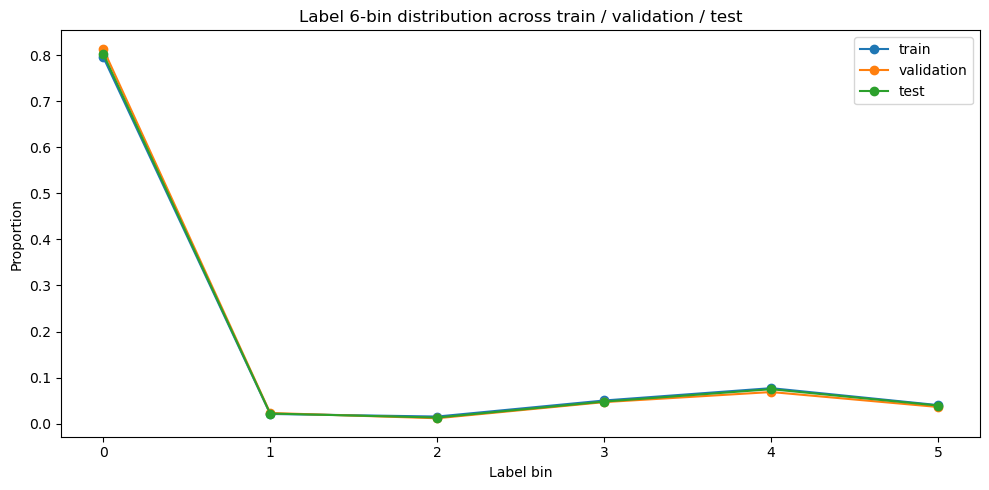

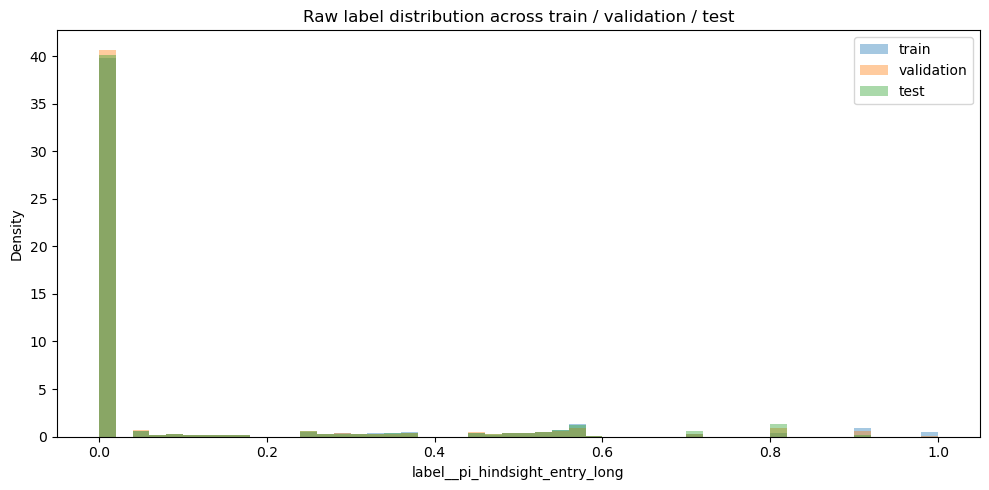

- Large ticker-level differences in positive_rate or high_quality_rate mean some tickers generate more hindsight opportunities than others.
- Large validation/test differences versus train suggest temporal distribution shift.
- If validation/test have much lower high_quality_rate, model performance may drop partly because the target distribution changed.
- For modelling, this supports reporting both regression metrics and bin/class distribution diagnostics.


In [27]:
ticker_col = "attr__ticker"
timestamp_col = "attr__timestamp"
bin_col = "label__pi_long_entry_bin6"

high_quality_threshold = 0.4
strong_threshold = 0.7

splits = {
    "train": df_train,
    "validation": df_valid,
    "test": df_test,
}


# Check required columns and add bin label

for split_name, df in splits.items():

    if target not in df.columns:
        raise ValueError(f"{target} is not found in {split_name}.")

    if ticker_col not in df.columns:
        raise ValueError(f"{ticker_col} is not found in {split_name}.")

    df[bin_col] = make_pi_hindsight_entry_long_6bins(df[target])

print("6-bin label created for train / validation / test.")


# Question 1:
# Does each ticker have very different label distribution?
  

def ticker_label_distribution(df, target, ticker_col, bin_col):
    """
    Summarise label distribution by ticker.
    """

    summary = (
        df.groupby(ticker_col, observed=True)[target]
        .agg(
            n_obs="count",
            mean_label="mean",
            std_label="std",
            median_label="median",
            min_label="min",
            max_label="max",
        )
        .reset_index()
    )

    rates = (
        df.groupby(ticker_col, observed=True)[target]
        .agg(
            zero_rate=lambda x: (x == 0).mean(),
            positive_rate=lambda x: (x > 0).mean(),
            high_quality_rate=lambda x: (x >= high_quality_threshold).mean(),
            strong_rate=lambda x: (x >= strong_threshold).mean(),
        )
        .reset_index()
    )

    summary = summary.merge(rates, on=ticker_col, how="left")

    bin_dist = (
        pd.crosstab(
            df[ticker_col],
            df[bin_col],
            normalize="index"
        )
        .rename(columns=lambda x: f"bin_{x}_rate")
        .reset_index()
    )

    summary = summary.merge(bin_dist, on=ticker_col, how="left")

    return summary


ticker_label_train = ticker_label_distribution(
    df_train,
    target,
    ticker_col,
    bin_col
)

ticker_label_train = ticker_label_train.sort_values(
    "positive_rate",
    ascending=False
)

print("Ticker-level label distribution: highest positive label rate")
display(ticker_label_train.head(10))

print("Ticker-level label distribution: lowest positive label rate")
display(ticker_label_train.tail(10))

ticker_label_train.to_csv(
    output_dir / "ticker_label_distribution_train.csv",
    index=False
)

print("Saved: ticker_label_distribution_train.csv")


 
# Cross-ticker variation summary
 

ticker_variation_summary = ticker_label_train[
    [
        "mean_label",
        "zero_rate",
        "positive_rate",
        "high_quality_rate",
        "strong_rate",
    ]
].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T

print("Cross-ticker variation summary")
display(ticker_variation_summary)

ticker_variation_summary.to_csv(
    output_dir / "ticker_label_distribution_variation_summary_train.csv"
)

print("Saved: ticker_label_distribution_variation_summary_train.csv")

# Most different tickers

most_positive_tickers = ticker_label_train.head(10)[
    [
        ticker_col,
        "n_obs",
        "mean_label",
        "zero_rate",
        "positive_rate",
        "high_quality_rate",
        "strong_rate",
    ]
]

least_positive_tickers = ticker_label_train.tail(10)[
    [
        ticker_col,
        "n_obs",
        "mean_label",
        "zero_rate",
        "positive_rate",
        "high_quality_rate",
        "strong_rate",
    ]
]

print("Tickers with highest positive label rate:")
display(most_positive_tickers)

print("Tickers with lowest positive label rate:")
display(least_positive_tickers)


  
# Question 2:
# Are train / validation / test label distributions consistent?
  

def split_label_summary(splits, target):
    """
    Compare raw label distribution across train / validation / test.
    """

    rows = []

    for split_name, df in splits.items():
        y = df[target].dropna()

        rows.append({
            "split": split_name,
            "n_obs": len(y),
            "mean_label": y.mean(),
            "std_label": y.std(),
            "min_label": y.min(),
            "p01": y.quantile(0.01),
            "p05": y.quantile(0.05),
            "p25": y.quantile(0.25),
            "median": y.quantile(0.50),
            "p75": y.quantile(0.75),
            "p95": y.quantile(0.95),
            "p99": y.quantile(0.99),
            "max_label": y.max(),
            "zero_rate": (y == 0).mean(),
            "positive_rate": (y > 0).mean(),
            "high_quality_rate": (y >= high_quality_threshold).mean(),
            "strong_rate": (y >= strong_threshold).mean(),
        })

    out = pd.DataFrame(rows)

    train_row = out.loc[out["split"] == "train"].iloc[0]

    for col in [
        "mean_label",
        "zero_rate",
        "positive_rate",
        "high_quality_rate",
        "strong_rate",
    ]:
        out[f"{col}_diff_vs_train"] = out[col] - train_row[col]

    return out


split_summary = split_label_summary(splits, target)

print("Train / validation / test raw label distribution summary")
display(split_summary)

split_summary.to_csv(
    output_dir / "split_label_distribution_summary.csv",
    index=False
)

print("Saved: split_label_distribution_summary.csv")


 
# 6-bin distribution by split
# Robust version: no KeyError 'bin'
 

bin_distribution_by_split = []

for split_name, df in splits.items():

    dist = (
        df[bin_col]
        .value_counts(normalize=True, dropna=False)
        .sort_index()
        .rename("rate")
        .reset_index()
    )

    # Make column names explicit and stable
    # This avoids pandas-version differences after reset_index()
    dist.columns = ["bin", "rate"]

    dist["split"] = split_name
    dist["meaning"] = dist["bin"].map(bin6_labels)

    bin_distribution_by_split.append(dist)

bin_distribution_by_split = pd.concat(
    bin_distribution_by_split,
    ignore_index=True
)

bin_distribution_by_split = bin_distribution_by_split[
    ["split", "bin", "meaning", "rate"]
].sort_values(["split", "bin"])

print("6-bin label distribution by split")
display(bin_distribution_by_split)

bin_distribution_by_split.to_csv(
    output_dir / "split_label_bin6_distribution.csv",
    index=False
)

print("Saved: split_label_bin6_distribution.csv")


 
# Pivot version for easier train / validation / test comparison
 

bin_distribution_pivot = (
    bin_distribution_by_split
    .pivot(index="bin", columns="split", values="rate")
    .reset_index()
)

for split_name in ["validation", "test"]:
    if split_name in bin_distribution_pivot.columns and "train" in bin_distribution_pivot.columns:
        bin_distribution_pivot[f"{split_name}_diff_vs_train"] = (
            bin_distribution_pivot[split_name] - bin_distribution_pivot["train"]
        )

bin_distribution_pivot["meaning"] = bin_distribution_pivot["bin"].map(bin6_labels)

print("6-bin label distribution pivot table")
display(bin_distribution_pivot)

bin_distribution_pivot.to_csv(
    output_dir / "split_label_bin6_distribution_pivot.csv",
    index=False
)

print("Saved: split_label_bin6_distribution_pivot.csv")


 
# Plot: label bin distribution across splits
 

plt.figure(figsize=(10, 5))

for split_name, df in splits.items():

    rates = (
        df[bin_col]
        .value_counts(normalize=True)
        .reindex(range(6), fill_value=0)
        .sort_index()
    )

    plt.plot(
        rates.index,
        rates.values,
        marker="o",
        label=split_name
    )

plt.title("Label 6-bin distribution across train / validation / test")
plt.xlabel("Label bin")
plt.ylabel("Proportion")
plt.xticks(range(6))
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "split_label_bin6_distribution.png", dpi=150)
plt.show()


 
# Plot: histogram of raw label values across splits
 

plt.figure(figsize=(10, 5))

for split_name, df in splits.items():

    plt.hist(
        df[target].dropna(),
        bins=50,
        alpha=0.4,
        density=True,
        label=split_name
    )

plt.title("Raw label distribution across train / validation / test")
plt.xlabel(target)
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "split_raw_label_distribution.png", dpi=150)
plt.show()


print("- Large ticker-level differences in positive_rate or high_quality_rate mean some tickers generate more hindsight opportunities than others.")
print("- Large validation/test differences versus train suggest temporal distribution shift.")
print("- If validation/test have much lower high_quality_rate, model performance may drop partly because the target distribution changed.")
print("- For modelling, this supports reporting both regression metrics and bin/class distribution diagnostics.")

### Safety Check

In [ ]:
def check_model_inputs(df_train, df_valid, df_test, feature_cols, target_col):
    print("Number of features:", len(feature_cols))
    
    for name, df in {
        "train": df_train,
        "valid": df_valid,
        "test": df_test
    }.items():
        print(f"\n{name.upper()}")
        print("Rows:", len(df))
        
        missing_features = [c for c in feature_cols if c not in df.columns]
        print("Missing feature columns:", len(missing_features))
        if missing_features:
            print(missing_features[:10])
        
        print("Target exists:", target_col in df.columns)
        
        X = df[feature_cols]
        y = df[target_col]
        
        print("X NaN count:", X.isna().sum().sum())
        print("X inf count:", np.isinf(X.to_numpy()).sum())
        print("y NaN count:", y.isna().sum())
        print("y unique values:", y.nunique())
        print("y distribution:")
        print(y.value_counts(normalize=True).sort_index().head(10))
check_model_inputs(
    df_train,
    df_valid,
    df_test,
     project_b_features,
    "label__pi_long_entry_bin6"
)

Number of features: 264

TRAIN
Rows: 167005
Missing feature columns: 0
Target exists: True
X NaN count: 0
X inf count: 0
y NaN count: 0
y unique values: 6
y distribution:
label__pi_long_entry_bin6
0    0.795994
1    0.021035
2    0.015443
3    0.050268
4    0.077052
5    0.040208
Name: proportion, dtype: Float64

VALID
Rows: 49073
Missing feature columns: 0
Target exists: True
X NaN count: 0
X inf count: 0
y NaN count: 0
y unique values: 6
y distribution:
label__pi_long_entry_bin6
0    0.813543
1    0.023149
2    0.011738
3    0.046787
4    0.068632
5     0.03615
Name: proportion, dtype: Float64

TEST
Rows: 56611
Missing feature columns: 0
Target exists: True
X NaN count: 0
X inf count: 0
y NaN count: 0
y unique values: 6
y distribution:
label__pi_long_entry_bin6
0    0.802883
1    0.021992
2    0.013231
3    0.047906
4    0.074773
5    0.039215
Name: proportion, dtype: Float64


## 5. Modeling utilities

### Target construction


In [29]:
target_cols = [
    "label__pi_hindsight_entry_long",
    "label__pi_long_entry_positive",
    "label__pi_long_entry_original",
    "label__pi_long_entry_bin6" 
]

for split_name, df in {
    "train": df_train,
    "valid": df_valid,
    "test": df_test
}.items():
    missing_targets = [c for c in target_cols if c not in df.columns]
    
    if missing_targets:
        raise ValueError(
            f"{split_name} is missing target columns: {missing_targets}"
        )

print("All target columns exist in train, valid, and test.")

All target columns exist in train, valid, and test.


In [30]:
def prepare_X_y(df_train, df_valid, df_test, feature_cols, target_col):
    """
    Convert X to float32 to reduce memory use.
    """
    X_train = df_train[feature_cols].astype(np.float32)
    X_valid = df_valid[feature_cols].astype(np.float32)
    X_test = df_test[feature_cols].astype(np.float32)
    
    y_train = df_train[target_col]
    y_valid = df_valid[target_col]
    y_test = df_test[target_col]
    
    return X_train, X_valid, X_test, y_train, y_valid, y_test

### Metrics functions

In [31]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # Correlations can fail if predictions are constant
    try:
        spearman = spearmanr(y_true, y_pred).correlation
    except Exception:
        spearman = np.nan
    
    try:
        pearson = pearsonr(y_true, y_pred)[0]
    except Exception:
        pearson = np.nan
    
    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Spearman": spearman,
        "Pearson": pearson
    }

In [32]:
def binary_classification_metrics(y_true, y_pred, y_proba=None):
    results = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
    }
    
    if y_proba is not None:
        try:
            results["ROC_AUC"] = roc_auc_score(y_true, y_proba)
        except Exception:
            results["ROC_AUC"] = np.nan
        
        try:
            results["PR_AUC"] = average_precision_score(y_true, y_proba)
        except Exception:
            results["PR_AUC"] = np.nan
    else:
        results["ROC_AUC"] = np.nan
        results["PR_AUC"] = np.nan
    
    return results

In [33]:
def multiclass_classification_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Macro_F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted_F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Mean_Absolute_Class_Error": np.mean(np.abs(y_true - y_pred))
    }

## 7. Regression experiment

In [34]:
def get_regression_models():
    models = {}
    
    models["DummyMean"] = DummyRegressor(strategy="mean")
    
    models["ElasticNet"] = ElasticNet(
        alpha=0.001,
        l1_ratio=0.5,
        random_state=RANDOM_STATE,
        max_iter=5000
    )
    
    models["RandomForest"] = RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=20,
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
    
    if HAS_LGBM:
        models["LightGBM"] = LGBMRegressor(
            n_estimators=500,
            learning_rate=0.03,
            num_leaves=31,
            max_depth=-1,
            min_child_samples=50,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    
    if HAS_XGB:
        models["XGBoost"] = XGBRegressor(
            n_estimators=500,
            learning_rate=0.03,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    
    models["MLP_3Layer"] = MLPRegressor(
        hidden_layer_sizes=(256, 128, 64),
        activation="relu",
        alpha=0.0001,
        learning_rate_init=0.001,
        early_stopping=True,
        validation_fraction=0.1,
        max_iter=100,
        random_state=RANDOM_STATE
    )
    
    return models

In [35]:
def run_regression_experiment(
    df_train,
    df_valid,
    df_test,
    feature_cols,
    feature_set_name,
    target_col="y_reg_pi_long"
):   
    X_train, X_valid, X_test, y_train, y_valid, y_test = prepare_X_y(
        df_train, df_valid, df_test, feature_cols, target_col
    )
    
    models = get_regression_models()
    rows = []
    fitted_models = {}
    
    for model_name, model in models.items():
        print(f"\nTraining regression model: {model_name}")
        
        model.fit(X_train, y_train)
        fitted_models[model_name] = model
        
        for split_name, X, y in [
            ("valid", X_valid, y_valid),
            ("test", X_test, y_test)
        ]:
            pred = model.predict(X)
            metrics = regression_metrics(y, pred)
            
            row = {
                "Task": "Regression",
                "Feature_Set": feature_set_name,
                "Target": target_col,
                "Model": model_name,
                "Split": split_name
            }
            row.update(metrics)
            rows.append(row)
    
    results = pd.DataFrame(rows)
    return results, fitted_models

In [ ]:
reg_results_topcorr, reg_models_topcorr = run_regression_experiment(
    df_train=df_train,
    df_valid=df_valid,
    df_test=df_test,
    feature_cols= project_b_features,
    feature_set_name=" project_b_features",
    target_col="label__pi_hindsight_entry_long"
)

reg_results_topcorr


Training regression model: DummyMean

Training regression model: ElasticNet


C:\Users\user\AppData\Local\Temp\ipykernel_31288\2522056932.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman = spearmanr(y_true, y_pred).correlation
C:\Users\user\AppData\Local\Temp\ipykernel_31288\2522056932.py:16: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson = pearsonr(y_true, y_pred)[0]
C:\Users\user\AppData\Local\Temp\ipykernel_31288\2522056932.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman = spearmanr(y_true, y_pred).correlation
C:\Users\user\AppData\Local\Temp\ipykernel_31288\2522056932.py:16: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson = pearsonr(y_true, y_pred)[0]



Training regression model: RandomForest

Training regression model: XGBoost

Training regression model: MLP_3Layer


,Task,Feature_Set,Target,Model,Split,MAE,RMSE,R2,Spearman,Pearson
0,Regression,project_b_fisrt_features,label__pi_hindsight_entry_long,DummyMean,valid,0.144364,0.203656,-0.003915,NaN,NaN
1,Regression,project_b_fisrt_features,label__pi_hindsight_entry_long,DummyMean,test,0.147656,0.206086,-0.001257,NaN,NaN
2,Regression,project_b_fisrt_features,label__pi_hindsight_entry_long,ElasticNet,valid,0.130842,0.199964,0.032147,0.189397,0.181082
3,Regression,project_b_fisrt_features,label__pi_hindsight_entry_long,ElasticNet,test,0.160225,0.209897,-0.038627,0.078069,0.087353
4,Regression,project_b_fisrt_features,label__pi_hindsight_entry_long,RandomForest,valid,0.133638,0.210367,-0.071172,0.068434,0.065028
5,Regression,project_b_fisrt_features,label__pi_hindsight_entry_long,RandomForest,test,0.122922,0.211102,-0.050593,0.083019,0.076281
6,Regression,project_b_fisrt_features,label__pi_hindsight_entry_long,XGBoost,valid,0.147464,0.209220,-0.059528,0.128106,0.132262
7,Regression,project_b_fisrt_features,label__pi_hindsight_entry_long,XGBoost,test,0.126767,0.208011,-0.020048,0.092552,0.120015
8,Regression,project_b_fisrt_features,label__pi_hindsight_entry_long,MLP_3Layer,valid,0.146616,0.260803,-0.646380,0.053970,0.060260
9,Regression,project_b_fisrt_features,label__pi_hindsight_entry_long,MLP_3Layer,test,0.146468,0.262775,-0.627853,0.012975,0.037777


## 8. Binary classification experiments

In [37]:
def get_binary_classification_models(y_train= None):
    models = {}
    
    models["DummyMostFrequent"] = DummyClassifier(
        strategy="most_frequent"
    )
    
    models["DummyStratified"] = DummyClassifier(
        strategy="stratified",
        random_state=RANDOM_STATE
    )
    
    models["LogisticRegression"] = LogisticRegression(
        penalty="l2",
        C=1.0,
        class_weight="balanced",
        solver="lbfgs",
        max_iter=1000,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    
    models["RandomForest"] = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=20,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
    
    if HAS_LGBM:
        models["LightGBM"] = LGBMClassifier(
            n_estimators=500,
            learning_rate=0.03,
            num_leaves=31,
            max_depth=-1,
            min_child_samples=50,
            subsample=0.8,
            colsample_bytree=0.8,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    
    if HAS_XGB:
        # XGBoost does not use class_weight like sklearn models.
        # For binary imbalance, use scale_pos_weight = number of negatives / number of positives.
        if y_train is not None:
            neg = (y_train == 0).sum()
            pos = (y_train == 1).sum()
            scale_pos_weight = neg / pos if pos > 0 else 1.0
        else:
            scale_pos_weight = 1.0

        models["XGBoost"] = XGBClassifier(
            n_estimators=500,
            learning_rate=0.03,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    
    models["MLP_3Layer"] = MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        activation="relu",
        alpha=0.0001,
        learning_rate_init=0.001,
        early_stopping=True,
        validation_fraction=0.1,
        max_iter=100,
        random_state=RANDOM_STATE
    )
    
    return models

In [38]:
def get_positive_proba(model, X):
    """
    Return probability for class 1 if model supports predict_proba.
    """
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)
        if proba.shape[1] == 2:
            return proba[:, 1]
        else:
            return None
    return None

In [39]:
def run_binary_classification_experiment(
    df_train,
    df_valid,
    df_test,
    feature_cols,
    feature_set_name,
    target_col="label__pi_long_entry_original"
):
    X_train, X_valid, X_test, y_train, y_valid, y_test = prepare_X_y(
        df_train, df_valid, df_test, feature_cols, target_col
    )
    
    y_train = y_train.astype(int)
    y_valid = y_valid.astype(int)
    y_test = y_test.astype(int)
    
    models = get_binary_classification_models(y_train =y_train)
    rows = []
    fitted_models = {}
    
    for model_name, model in models.items():
        print(f"\nTraining binary classification model: {model_name}")
        
        model.fit(X_train, y_train)
        fitted_models[model_name] = model
        
        for split_name, X, y in [
            ("valid", X_valid, y_valid),
            ("test", X_test, y_test)
        ]:
            pred = model.predict(X)
            proba = get_positive_proba(model, X)
            
            metrics = binary_classification_metrics(y, pred, proba)
            
            row = {
                "Task": "Binary Classification",
                "Feature_Set": feature_set_name,
                "Target": target_col,
                "Model": model_name,
                "Split": split_name
            }
            row.update(metrics)
            rows.append(row)
    
    results = pd.DataFrame(rows)
    return results, fitted_models

### Binary, original (y>0.4)


In [ ]:
bin_original_results_topcorr, bin_original_models_topcorr = run_binary_classification_experiment(
    df_train=df_train,
    df_valid=df_valid,
    df_test=df_test,
    feature_cols= project_b_features,
    feature_set_name=" project_b_features",
    target_col="label__pi_long_entry_original"
)

bin_original_results_topcorr


Training binary classification model: DummyMostFrequent

Training binary classification model: DummyStratified

Training binary classification model: LogisticRegression

Training binary classification model: RandomForest

Training binary classification model: XGBoost

Training binary classification model: MLP_3Layer


,Task,Feature_Set,Target,Model,Split,Accuracy,Balanced_Accuracy,F1,Precision,Recall,ROC_AUC,PR_AUC
0,Binary Classification,project_b_fisrt_features,label__pi_long_entry_original,DummyMostFrequent,valid,0.895217,0.500000,0.000000,0.000000,0.000000,0.500000,0.104783
1,Binary Classification,project_b_fisrt_features,label__pi_long_entry_original,DummyMostFrequent,test,0.886012,0.500000,0.000000,0.000000,0.000000,0.500000,0.113988
2,Binary Classification,project_b_fisrt_features,label__pi_long_entry_original,DummyStratified,valid,0.803619,0.502758,0.115303,0.109198,0.122131,0.502758,0.105322
3,Binary Classification,project_b_fisrt_features,label__pi_long_entry_original,DummyStratified,test,0.795517,0.499432,0.114443,0.113008,0.115915,0.499432,0.113875
4,Binary Classification,project_b_fisrt_features,label__pi_long_entry_original,LogisticRegression,valid,0.869684,0.520253,0.111682,0.195430,0.078180,0.618864,0.153511
5,Binary Classification,project_b_fisrt_features,label__pi_long_entry_original,LogisticRegression,test,0.618166,0.523103,0.192770,0.126986,0.399969,0.528047,0.134252
6,Binary Classification,project_b_fisrt_features,label__pi_long_entry_original,RandomForest,valid,0.893811,0.501790,0.011383,0.232558,0.005834,0.588264,0.149025
7,Binary Classification,project_b_fisrt_features,label__pi_long_entry_original,RandomForest,test,0.885906,0.499940,0.000000,0.000000,0.000000,0.550887,0.146039
8,Binary Classification,project_b_fisrt_features,label__pi_long_entry_original,XGBoost,valid,0.883072,0.506181,0.050000,0.168151,0.029366,0.531610,0.117413
9,Binary Classification,project_b_fisrt_features,label__pi_long_entry_original,XGBoost,test,0.883786,0.505563,0.029789,0.307927,0.015652,0.499221,0.131830


### validation-tuned threshold

In [41]:
def binary_classification_metrics_from_proba(y_true, y_proba, threshold=0.5):
    """
    Compute binary classification metrics using predicted probabilities
    and a selected probability threshold.
    """
    y_pred = (y_proba >= threshold).astype(int)

    metrics = {
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_proba),
        "PR_AUC": average_precision_score(y_true, y_proba),
        "Positive_Pred_Rate": y_pred.mean()
    }

    return metrics

In [42]:
def tune_threshold_on_valid(
    y_valid,
    valid_proba,
    tuning_metric="F1",
    thresholds=None
):
    """
    Tune probability threshold on the validation set.

    Recommended tuning_metric:
    - "F1"
    - "Balanced_Accuracy"
    - "Precision"
    - "Recall"

    Do not use ROC_AUC or PR_AUC as tuning_metric because they are
    threshold-independent ranking metrics.
    """
    if thresholds is None:
        thresholds = np.arange(0.01, 0.51, 0.01)

    rows = []

    for threshold in thresholds:
        metrics = binary_classification_metrics_from_proba(
            y_true=y_valid,
            y_proba=valid_proba,
            threshold=threshold
        )
        rows.append(metrics)

    threshold_results = pd.DataFrame(rows)

    best_idx = threshold_results[tuning_metric].idxmax()
    best_threshold = threshold_results.loc[best_idx, "Threshold"]

    return best_threshold, threshold_results

In [43]:
def run_binary_classification_experiment_with_threshold_tuning(
    df_train,
    df_valid,
    df_test,
    feature_cols,
    feature_set_name,
    target_col="label__pi_long_entry_original",
    tuning_metric="F1",
    thresholds=None
):
    X_train, X_valid, X_test, y_train, y_valid, y_test = prepare_X_y(
        df_train, df_valid, df_test, feature_cols, target_col
    )

    y_train = y_train.astype(int)
    y_valid = y_valid.astype(int)
    y_test = y_test.astype(int)

    models = get_binary_classification_models(y_train=y_train)
    rows = []
    fitted_models = {}
    threshold_diagnostics = {}

    for model_name, model in models.items():
        print(f"\nTraining binary classification model: {model_name}")

        model.fit(X_train, y_train)
        fitted_models[model_name] = model

        valid_proba = get_positive_proba(model, X_valid)
        test_proba = get_positive_proba(model, X_test)

        if valid_proba is None or test_proba is None:
            print(f"Skipping threshold tuning for {model_name}: no valid predict_proba output.")
            continue

        best_threshold, threshold_results = tune_threshold_on_valid(
            y_valid=y_valid,
            valid_proba=valid_proba,
            tuning_metric=tuning_metric,
            thresholds=thresholds
        )

        threshold_diagnostics[model_name] = threshold_results

        print(f"Best threshold selected on validation set: {best_threshold:.2f}")

        for split_name, y, proba in [
            ("valid", y_valid, valid_proba),
            ("test", y_test, test_proba)
        ]:
            metrics = binary_classification_metrics_from_proba(
                y_true=y,
                y_proba=proba,
                threshold=best_threshold
            )

            row = {
                "Task": "Binary Classification",
                "Feature_Set": feature_set_name,
                "Target": target_col,
                "Model": model_name,
                "Split": split_name,
                "Tuning_Metric": tuning_metric
            }

            row.update(metrics)
            rows.append(row)

    results = pd.DataFrame(rows)

    return results, fitted_models, threshold_diagnostics

#### F1 tuning

In [ ]:
bin_original_results_topcorr_tuned_f1, bin_original_models_topcorr_tuned_f1, bin_original_threshold_diag_f1 = (
    run_binary_classification_experiment_with_threshold_tuning(
        df_train=df_train,
        df_valid=df_valid,
        df_test=df_test,
        feature_cols= project_b_features,
        feature_set_name=" project_b_features",
        target_col="label__pi_long_entry_original",
        tuning_metric="F1"
    )
)

bin_original_results_topcorr_tuned_f1


Training binary classification model: DummyMostFrequent
Best threshold selected on validation set: 0.01

Training binary classification model: DummyStratified
Best threshold selected on validation set: 0.01

Training binary classification model: LogisticRegression
Best threshold selected on validation set: 0.23

Training binary classification model: RandomForest
Best threshold selected on validation set: 0.28

Training binary classification model: XGBoost
Best threshold selected on validation set: 0.09

Training binary classification model: MLP_3Layer
Best threshold selected on validation set: 0.01


,Task,Feature_Set,Target,Model,Split,Tuning_Metric,Threshold,Accuracy,Balanced_Accuracy,F1,Precision,Recall,ROC_AUC,PR_AUC,Positive_Pred_Rate
0,Binary Classification,project_b_fisrt_features,label__pi_long_entry_original,DummyMostFrequent,valid,F1,0.01,0.895217,0.500000,0.000000,0.000000,0.000000,0.500000,0.104783,0.000000
1,Binary Classification,project_b_fisrt_features,label__pi_long_entry_original,DummyMostFrequent,test,F1,0.01,0.886012,0.500000,0.000000,0.000000,0.000000,0.500000,0.113988,0.000000
2,Binary Classification,project_b_fisrt_features,label__pi_long_entry_original,DummyStratified,valid,F1,0.01,0.803619,0.502758,0.115303,0.109198,0.122131,0.502758,0.105322,0.117193
3,Binary Classification,project_b_fisrt_features,label__pi_long_entry_original,DummyStratified,test,F1,0.01,0.795517,0.499432,0.114443,0.113008,0.115915,0.499432,0.113875,0.116921
4,Binary Classification,project_b_fisrt_features,label__pi_long_entry_original,LogisticRegression,valid,F1,0.23,0.666619,0.585334,0.232717,0.153337,0.482497,0.618864,0.153511,0.329713
5,Binary Classification,project_b_fisrt_features,label__pi_long_entry_original,LogisticRegression,test,F1,0.23,0.329583,0.501827,0.197764,0.114500,0.724934,0.528047,0.134252,0.721697
6,Binary Classification,project_b_fisrt_features,label__pi_long_entry_original,RandomForest,valid,F1,0.28,0.655371,0.561965,0.212516,0.139709,0.443796,0.588264,0.149025,0.332851
7,Binary Classification,project_b_fisrt_features,label__pi_long_entry_original,RandomForest,test,F1,0.28,0.698433,0.536803,0.198422,0.142337,0.327445,0.550887,0.146039,0.262228
8,Binary Classification,project_b_fisrt_features,label__pi_long_entry_original,XGBoost,valid,F1,0.09,0.367127,0.529932,0.195935,0.113013,0.735900,0.531610,0.117413,0.682310
9,Binary Classification,project_b_fisrt_features,label__pi_long_entry_original,XGBoost,test,F1,0.09,0.279221,0.484006,0.191584,0.109834,0.749264,0.499221,0.131830,0.777605


#### Balanced Accuracy tuning

In [ ]:
bin_original_results_topcorr_tuned_balacc, bin_original_models_topcorr_tuned_balacc, bin_original_threshold_diag_balacc = (
    run_binary_classification_experiment_with_threshold_tuning(
        df_train=df_train,
        df_valid=df_valid,
        df_test=df_test,
        feature_cols= project_b_features,
        feature_set_name=" project_b_features",
        target_col="label__pi_long_entry_original",
        tuning_metric="Balanced_Accuracy"
    )
)

bin_original_results_topcorr_tuned_balacc


Training binary classification model: DummyMostFrequent
Best threshold selected on validation set: 0.01

Training binary classification model: DummyStratified
Best threshold selected on validation set: 0.01

Training binary classification model: LogisticRegression
Best threshold selected on validation set: 0.18

Training binary classification model: RandomForest
Best threshold selected on validation set: 0.28

Training binary classification model: XGBoost
Best threshold selected on validation set: 0.09

Training binary classification model: MLP_3Layer
Best threshold selected on validation set: 0.02


,Task,Feature_Set,Target,Model,Split,Tuning_Metric,Threshold,Accuracy,Balanced_Accuracy,F1,Precision,Recall,ROC_AUC,PR_AUC,Positive_Pred_Rate
0,Binary Classification,project_b_fisrt_features,label__pi_long_entry_original,DummyMostFrequent,valid,Balanced_Accuracy,0.01,0.895217,0.500000,0.000000,0.000000,0.000000,0.500000,0.104783,0.000000
1,Binary Classification,project_b_fisrt_features,label__pi_long_entry_original,DummyMostFrequent,test,Balanced_Accuracy,0.01,0.886012,0.500000,0.000000,0.000000,0.000000,0.500000,0.113988,0.000000
2,Binary Classification,project_b_fisrt_features,label__pi_long_entry_original,DummyStratified,valid,Balanced_Accuracy,0.01,0.803619,0.502758,0.115303,0.109198,0.122131,0.502758,0.105322,0.117193
3,Binary Classification,project_b_fisrt_features,label__pi_long_entry_original,DummyStratified,test,Balanced_Accuracy,0.01,0.795517,0.499432,0.114443,0.113008,0.115915,0.499432,0.113875,0.116921
4,Binary Classification,project_b_fisrt_features,label__pi_long_entry_original,LogisticRegression,valid,Balanced_Accuracy,0.18,0.567318,0.589714,0.230382,0.141578,0.618047,0.618864,0.153511,0.457421
5,Binary Classification,project_b_fisrt_features,label__pi_long_entry_original,LogisticRegression,test,Balanced_Accuracy,0.18,0.285298,0.503301,0.200395,0.114844,0.785681,0.528047,0.134252,0.779831
6,Binary Classification,project_b_fisrt_features,label__pi_long_entry_original,RandomForest,valid,Balanced_Accuracy,0.28,0.655371,0.561965,0.212516,0.139709,0.443796,0.588264,0.149025,0.332851
7,Binary Classification,project_b_fisrt_features,label__pi_long_entry_original,RandomForest,test,Balanced_Accuracy,0.28,0.698433,0.536803,0.198422,0.142337,0.327445,0.550887,0.146039,0.262228
8,Binary Classification,project_b_fisrt_features,label__pi_long_entry_original,XGBoost,valid,Balanced_Accuracy,0.09,0.367127,0.529932,0.195935,0.113013,0.735900,0.531610,0.117413,0.682310
9,Binary Classification,project_b_fisrt_features,label__pi_long_entry_original,XGBoost,test,Balanced_Accuracy,0.09,0.279221,0.484006,0.191584,0.109834,0.749264,0.499221,0.131830,0.777605


In [46]:
bin_original_results_topcorr_tuned_f1[
    ["Model", "Split", "Tuning_Metric", "Threshold", "Accuracy", 
     "Balanced_Accuracy", "F1", "Precision", "Recall", 
     "ROC_AUC", "PR_AUC", "Positive_Pred_Rate"]
]

,Model,Split,Tuning_Metric,Threshold,Accuracy,Balanced_Accuracy,F1,Precision,Recall,ROC_AUC,PR_AUC,Positive_Pred_Rate
0,DummyMostFrequent,valid,F1,0.01,0.895217,0.500000,0.000000,0.000000,0.000000,0.500000,0.104783,0.000000
1,DummyMostFrequent,test,F1,0.01,0.886012,0.500000,0.000000,0.000000,0.000000,0.500000,0.113988,0.000000
2,DummyStratified,valid,F1,0.01,0.803619,0.502758,0.115303,0.109198,0.122131,0.502758,0.105322,0.117193
3,DummyStratified,test,F1,0.01,0.795517,0.499432,0.114443,0.113008,0.115915,0.499432,0.113875,0.116921
4,LogisticRegression,valid,F1,0.23,0.666619,0.585334,0.232717,0.153337,0.482497,0.618864,0.153511,0.329713
5,LogisticRegression,test,F1,0.23,0.329583,0.501827,0.197764,0.114500,0.724934,0.528047,0.134252,0.721697
6,RandomForest,valid,F1,0.28,0.655371,0.561965,0.212516,0.139709,0.443796,0.588264,0.149025,0.332851
7,RandomForest,test,F1,0.28,0.698433,0.536803,0.198422,0.142337,0.327445,0.550887,0.146039,0.262228
8,XGBoost,valid,F1,0.09,0.367127,0.529932,0.195935,0.113013,0.735900,0.531610,0.117413,0.682310
9,XGBoost,test,F1,0.09,0.279221,0.484006,0.191584,0.109834,0.749264,0.499221,0.131830,0.777605


In [47]:
# for model_name in ["RandomForest", "XGBoost", "LogisticRegression"]:
#     if model_name in bin_original_threshold_diag_f1:
#         display(
#             bin_original_threshold_diag_f1[model_name]
#             .sort_values("F1", ascending=False)
#             .head(10)
#         )

### Binary, >0

In [ ]:
bin_positive_results_topcorr, bin_positive_models_topcorr = run_binary_classification_experiment(
    df_train=df_train,
    df_valid=df_valid,
    df_test=df_test,
    feature_cols= project_b_features,
    feature_set_name=" project_b_features",
    target_col="label__pi_long_entry_positive"
)

bin_positive_results_topcorr


Training binary classification model: DummyMostFrequent

Training binary classification model: DummyStratified

Training binary classification model: LogisticRegression

Training binary classification model: RandomForest

Training binary classification model: XGBoost

Training binary classification model: MLP_3Layer


c:\Users\user\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


,Task,Feature_Set,Target,Model,Split,Accuracy,Balanced_Accuracy,F1,Precision,Recall,ROC_AUC,PR_AUC
0,Binary Classification,project_b_fisrt_features,label__pi_long_entry_positive,DummyMostFrequent,valid,0.813543,0.500000,0.000000,0.000000,0.000000,0.500000,0.186457
1,Binary Classification,project_b_fisrt_features,label__pi_long_entry_positive,DummyMostFrequent,test,0.802883,0.500000,0.000000,0.000000,0.000000,0.500000,0.197117
2,Binary Classification,project_b_fisrt_features,label__pi_long_entry_positive,DummyStratified,valid,0.687038,0.501437,0.196673,0.188604,0.205464,0.501437,0.186898
3,Binary Classification,project_b_fisrt_features,label__pi_long_entry_positive,DummyStratified,test,0.679356,0.499035,0.198446,0.195612,0.201362,0.499035,0.196814
4,Binary Classification,project_b_fisrt_features,label__pi_long_entry_positive,LogisticRegression,valid,0.795733,0.524267,0.142955,0.328358,0.091366,0.624079,0.264988
5,Binary Classification,project_b_fisrt_features,label__pi_long_entry_positive,LogisticRegression,test,0.582343,0.521783,0.284772,0.214941,0.421812,0.528350,0.231680
6,Binary Classification,project_b_fisrt_features,label__pi_long_entry_positive,RandomForest,valid,0.810935,0.506779,0.041133,0.378327,0.021749,0.607657,0.259249
7,Binary Classification,project_b_fisrt_features,label__pi_long_entry_positive,RandomForest,test,0.803642,0.510142,0.048939,0.540643,0.025630,0.561891,0.263535
8,Binary Classification,project_b_fisrt_features,label__pi_long_entry_positive,XGBoost,valid,0.794836,0.504719,0.071046,0.228081,0.042077,0.525037,0.199783
9,Binary Classification,project_b_fisrt_features,label__pi_long_entry_positive,XGBoost,test,0.802123,0.513962,0.070836,0.476031,0.038265,0.522104,0.242503


In [ ]:
# threhold tuning
bin_positive_results_topcorr_tuned_f1, bin_positive_models_topcorr_tuned_f1, bin_positive_threshold_diag_f1 = (
    run_binary_classification_experiment_with_threshold_tuning(
        df_train=df_train,
        df_valid=df_valid,
        df_test=df_test,
        feature_cols= project_b_features,
        feature_set_name=" project_b_features",
        target_col="label__pi_long_entry_positive",
        tuning_metric="F1"
    )
)


Training binary classification model: DummyMostFrequent
Best threshold selected on validation set: 0.01

Training binary classification model: DummyStratified
Best threshold selected on validation set: 0.01

Training binary classification model: LogisticRegression
Best threshold selected on validation set: 0.18

Training binary classification model: RandomForest
Best threshold selected on validation set: 0.28

Training binary classification model: XGBoost
Best threshold selected on validation set: 0.08

Training binary classification model: MLP_3Layer


c:\Users\user\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Best threshold selected on validation set: 0.01


## 8. 6-bin multiclass experiment

In [50]:
def get_multiclass_classification_models():
    models = {}
    
    models["DummyMostFrequent"] = DummyClassifier(
        strategy="most_frequent"
    )
    
    models["DummyStratified"] = DummyClassifier(
        strategy="stratified",
        random_state=RANDOM_STATE
    )
    
    models["MultinomialLogistic"] = LogisticRegression(
        penalty="l2",
        C=1.0,
        class_weight="balanced",
        solver="lbfgs",
        multi_class="multinomial",
        max_iter=1000,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    
    models["RandomForest"] = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=20,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
    
    if HAS_LGBM:
        models["LightGBM"] = LGBMClassifier(
            n_estimators=500,
            learning_rate=0.03,
            num_leaves=31,
            max_depth=-1,
            min_child_samples=50,
            subsample=0.8,
            colsample_bytree=0.8,
            class_weight="balanced",
            objective="multiclass",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    
    if HAS_XGB:
        models["XGBoost"] = XGBClassifier(
            n_estimators=500,
            learning_rate=0.03,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="multi:softprob",
            eval_metric="mlogloss",
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    
    models["MLP_3Layer"] = MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        activation="relu",
        alpha=0.0001,
        learning_rate_init=0.001,
        early_stopping=True,
        validation_fraction=0.1,
        max_iter=100,
        random_state=RANDOM_STATE
    )
    
    return models

In [51]:
def run_multiclass_classification_experiment(
    df_train,
    df_valid,
    df_test,
    feature_cols,
    feature_set_name,
    target_col="label__pi_long_entry_bin6"
):
    X_train, X_valid, X_test, y_train, y_valid, y_test = prepare_X_y(
        df_train, df_valid, df_test, feature_cols, target_col
    )
    
    y_train = y_train.astype(int)
    y_valid = y_valid.astype(int)
    y_test = y_test.astype(int)
    
    models = get_multiclass_classification_models()
    rows = []
    fitted_models = {}
    
    for model_name, model in models.items():
        print(f"\nTraining multiclass classification model: {model_name}")
        
        model.fit(X_train, y_train)
        fitted_models[model_name] = model
        
        for split_name, X, y in [
            ("valid", X_valid, y_valid),
            ("test", X_test, y_test)
        ]:
            pred = model.predict(X)
            metrics = multiclass_classification_metrics(y, pred)
            
            row = {
                "Task": "6-bin Classification",
                "Feature_Set": feature_set_name,
                "Target": target_col,
                "Model": model_name,
                "Split": split_name
            }
            row.update(metrics)
            rows.append(row)
    
    results = pd.DataFrame(rows)
    return results, fitted_models

In [ ]:
bin6_results_topcorr, bin6_models_topcorr = run_multiclass_classification_experiment(
    df_train=df_train,
    df_valid=df_valid,
    df_test=df_test,
    feature_cols= project_b_features,
    feature_set_name=" project_b_features",
    target_col="label__pi_long_entry_bin6"
)

bin6_results_topcorr


Training multiclass classification model: DummyMostFrequent

Training multiclass classification model: DummyStratified

Training multiclass classification model: MultinomialLogistic


c:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Training multiclass classification model: RandomForest

Training multiclass classification model: XGBoost

Training multiclass classification model: MLP_3Layer


,Task,Feature_Set,Target,Model,Split,Accuracy,Balanced_Accuracy,Macro_F1,Weighted_F1,Mean_Absolute_Class_Error
0,6-bin Classification,project_b_fisrt_features,label__pi_long_entry_bin6,DummyMostFrequent,valid,0.813543,0.166667,0.149531,0.729900,0.642268
1,6-bin Classification,project_b_fisrt_features,label__pi_long_entry_bin6,DummyMostFrequent,test,0.802883,0.166667,0.148444,0.715100,0.687340
2,6-bin Classification,project_b_fisrt_features,label__pi_long_entry_bin6,DummyStratified,valid,0.658386,0.168740,0.168494,0.664521,1.142339
3,6-bin Classification,project_b_fisrt_features,label__pi_long_entry_bin6,DummyStratified,test,0.651993,0.167737,0.167728,0.654087,1.164067
4,6-bin Classification,project_b_fisrt_features,label__pi_long_entry_bin6,MultinomialLogistic,valid,0.582601,0.222320,0.181408,0.636096,1.043466
5,6-bin Classification,project_b_fisrt_features,label__pi_long_entry_bin6,MultinomialLogistic,test,0.172670,0.216627,0.101134,0.249342,1.952306
6,6-bin Classification,project_b_fisrt_features,label__pi_long_entry_bin6,RandomForest,valid,0.804475,0.174083,0.163369,0.730170,0.653496
7,6-bin Classification,project_b_fisrt_features,label__pi_long_entry_bin6,RandomForest,test,0.795428,0.177002,0.168042,0.719206,0.689354
8,6-bin Classification,project_b_fisrt_features,label__pi_long_entry_bin6,XGBoost,valid,0.813319,0.166711,0.149713,0.729907,0.642960
9,6-bin Classification,project_b_fisrt_features,label__pi_long_entry_bin6,XGBoost,test,0.802900,0.167122,0.149409,0.715412,0.686898


## 10. Model Comparison


In [53]:
all_results_topcorr = pd.concat(
    [
        reg_results_topcorr,
        bin_original_results_topcorr,
        bin_original_results_topcorr_tuned_f1,
        bin_original_results_topcorr_tuned_balacc,
        bin_positive_results_topcorr,
        bin6_results_topcorr
    ],
    ignore_index=True
)

all_results_topcorr

,Task,Feature_Set,Target,Model,Split,MAE,RMSE,R2,Spearman,Pearson,...,Precision,Recall,ROC_AUC,PR_AUC,Tuning_Metric,Threshold,Positive_Pred_Rate,Macro_F1,Weighted_F1,Mean_Absolute_Class_Error
0,Regression,project_b_fisrt_features,label__pi_hindsight_entry_long,DummyMean,valid,0.144364,0.203656,-0.003915,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Regression,project_b_fisrt_features,label__pi_hindsight_entry_long,DummyMean,test,0.147656,0.206086,-0.001257,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Regression,project_b_fisrt_features,label__pi_hindsight_entry_long,ElasticNet,valid,0.130842,0.199964,0.032147,0.189397,0.181082,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Regression,project_b_fisrt_features,label__pi_hindsight_entry_long,ElasticNet,test,0.160225,0.209897,-0.038627,0.078069,0.087353,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Regression,project_b_fisrt_features,label__pi_hindsight_entry_long,RandomForest,valid,0.133638,0.210367,-0.071172,0.068434,0.065028,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,6-bin Classification,project_b_fisrt_features,label__pi_long_entry_bin6,RandomForest,test,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.168042,0.719206,0.689354
66,6-bin Classification,project_b_fisrt_features,label__pi_long_entry_bin6,XGBoost,valid,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.149713,0.729907,0.642960
67,6-bin Classification,project_b_fisrt_features,label__pi_long_entry_bin6,XGBoost,test,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.149409,0.715412,0.686898
68,6-bin Classification,project_b_fisrt_features,label__pi_long_entry_bin6,MLP_3Layer,valid,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.178634,0.699671,0.974996


In [54]:
all_results_topcorr[all_results_topcorr["Split"] == "valid"].sort_values(
    by=["Task", "PR_AUC", "Macro_F1", "RMSE"],
    ascending=[True, False, False, True]
)

,Task,Feature_Set,Target,Model,Split,MAE,RMSE,R2,Spearman,Pearson,...,Precision,Recall,ROC_AUC,PR_AUC,Tuning_Metric,Threshold,Positive_Pred_Rate,Macro_F1,Weighted_F1,Mean_Absolute_Class_Error
62,6-bin Classification,project_b_fisrt_features,label__pi_long_entry_bin6,MultinomialLogistic,valid,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.181408,0.636096,1.043466
68,6-bin Classification,project_b_fisrt_features,label__pi_long_entry_bin6,MLP_3Layer,valid,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.178634,0.699671,0.974996
60,6-bin Classification,project_b_fisrt_features,label__pi_long_entry_bin6,DummyStratified,valid,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.168494,0.664521,1.142339
64,6-bin Classification,project_b_fisrt_features,label__pi_long_entry_bin6,RandomForest,valid,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.163369,0.730170,0.653496
66,6-bin Classification,project_b_fisrt_features,label__pi_long_entry_bin6,XGBoost,valid,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.149713,0.729907,0.642960
58,6-bin Classification,project_b_fisrt_features,label__pi_long_entry_bin6,DummyMostFrequent,valid,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.149531,0.729900,0.642268
50,Binary Classification,project_b_fisrt_features,label__pi_long_entry_positive,LogisticRegression,valid,NaN,NaN,NaN,NaN,NaN,...,0.328358,0.091366,0.624079,0.264988,NaN,NaN,NaN,NaN,NaN,NaN
52,Binary Classification,project_b_fisrt_features,label__pi_long_entry_positive,RandomForest,valid,NaN,NaN,NaN,NaN,NaN,...,0.378327,0.021749,0.607657,0.259249,NaN,NaN,NaN,NaN,NaN,NaN
56,Binary Classification,project_b_fisrt_features,label__pi_long_entry_positive,MLP_3Layer,valid,NaN,NaN,NaN,NaN,NaN,...,0.253740,0.240984,0.559105,0.228941,NaN,NaN,NaN,NaN,NaN,NaN
54,Binary Classification,project_b_fisrt_features,label__pi_long_entry_positive,XGBoost,valid,NaN,NaN,NaN,NaN,NaN,...,0.228081,0.042077,0.525037,0.199783,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
all_results_topcorr[all_results_topcorr["Split"] == "test"].sort_values(
    by=["Task", "PR_AUC", "Macro_F1", "RMSE"],
    ascending=[True, False, False, True]
)
all_results_topcorr.to_csv("model_results_top_corr_features.csv", index=False)

In [ ]:
model_name = "LightGBM" if HAS_LGBM else "RandomForest"

model = bin6_models_topcorr[model_name]

X_test = df_test[ project_b_features].astype(np.float32)
y_test = df_test["label__pi_long_entry_bin6"].astype(int)

y_pred = model.predict(X_test)

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))

Confusion matrix:
[[44863   402     0     0    88    99]
 [ 1172    43     0     0    23     7]
 [  733     8     0     0     6     2]
 [ 2589    64     0     0    40    19]
 [ 4006   128     0     1    72    26]
 [ 2057    70     0     1    40    52]]

Classification report:
              precision    recall  f1-score   support

           0       0.81      0.99      0.89     45452
           1       0.06      0.03      0.04      1245
           2       0.00      0.00      0.00       749
           3       0.00      0.00      0.00      2712
           4       0.27      0.02      0.03      4233
           5       0.25      0.02      0.04      2220

    accuracy                           0.80     56611
   macro avg       0.23      0.18      0.17     56611
weighted avg       0.68      0.80      0.72     56611



In [ ]:
model_name = "LightGBM" if HAS_LGBM else "RandomForest"

model = bin_original_models_topcorr[model_name]

X_test = df_test[ project_b_features].astype(np.float32)
y_test = df_test["label__pi_long_entry_original"].astype(int)

y_pred = model.predict(X_test)
y_proba = get_positive_proba(model, X_test)

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))

if y_proba is not None:
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))
    print("PR-AUC:", average_precision_score(y_test, y_proba))

Confusion matrix:
[[50152     6]
 [ 6453     0]]

Classification report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     50158
           1       0.00      0.00      0.00      6453

    accuracy                           0.89     56611
   macro avg       0.44      0.50      0.47     56611
weighted avg       0.79      0.89      0.83     56611

ROC-AUC: 0.5508867787492437
PR-AUC: 0.14603915495302866


## 11. Confusion matrix / class-wise diagnostics

# Project B — Subgroup Performance Diagnostics

This section evaluates the **binary meaningful-entry target** (`label >= 0.4`) by:

1. Year
2. Industry / sector
3. Ticker

The decision threshold is selected **once from the full validation set** and is then kept fixed for every subgroup and for the test set. This avoids subgroup-specific threshold overfitting and test leakage.

> Run the earlier data preparation, target construction, model utility, and Project B model cells before running this section.

In [58]:
# Configuration
from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
)

# Update this only if project_b_model_features has not already been created.
PROJECT_B_FEATURE_FILE = Path(
    "C:/Users/user/Downloads/universe_100_full_post_normalisation_0527/feature_project_b.txt"
)

TARGET_COL = "label__pi_long_entry_original"   # binary label: original score >= 0.4
MODEL_NAME = "RandomForest"
TUNING_METRIC = "F1"

# Minimum subgroup sizes used for reporting.
MIN_YEAR_SAMPLES = 100
MIN_YEAR_POSITIVES = 5
MIN_INDUSTRY_SAMPLES = 300
MIN_INDUSTRY_POSITIVES = 20
MIN_TICKER_SAMPLES = 100
MIN_TICKER_POSITIVES = 10

In [59]:
# Build or validate the Project B feature set.
# Existing project_b_model_features will be reused if it is already in memory.
if "project_b_model_features" not in globals():
    if not PROJECT_B_FEATURE_FILE.exists():
        raise FileNotFoundError(
            f"Project B feature file was not found: {PROJECT_B_FEATURE_FILE}"
        )

    with open(PROJECT_B_FEATURE_FILE, "r", encoding="utf-8") as f:
        raw_project_b_features = [line.strip() for line in f if line.strip()]

    project_b_features = [
        c if c.startswith("feature__") else f"feature__{c}"
        for c in raw_project_b_features
    ]

    project_b_model_features = [
        c for c in project_b_features if c in df_train.columns
    ]
    project_b_missing_features = [
        c for c in project_b_features if c not in df_train.columns
    ]
else:
    project_b_missing_features = [
        c for c in project_b_model_features if c not in df_train.columns
    ]

print("Project B model features available:", len(project_b_model_features))
print("Missing Project B features:", len(project_b_missing_features))

if project_b_missing_features:
    print("First missing features:", project_b_missing_features[:20])

if not project_b_model_features:
    raise ValueError("No Project B features are available in df_train.")

Project B model features available: 264
Missing Project B features: 0


In [60]:
# Obtain the tuned Project B binary model.
# Reuse earlier fitted outputs when available; otherwise run the experiment now.
required_result_name = "bin_original_results_project_b_tuned_f1"
required_model_name = "bin_original_models_project_b_tuned_f1"

if required_result_name not in globals() or required_model_name not in globals():
    print("Project B tuned model was not found in memory. Training it now...")

    (
        bin_original_results_project_b_tuned_f1,
        bin_original_models_project_b_tuned_f1,
        bin_original_threshold_diag_project_b_f1,
    ) = run_binary_classification_experiment_with_threshold_tuning(
        df_train=df_train,
        df_valid=df_valid,
        df_test=df_test,
        feature_cols=project_b_model_features,
        feature_set_name="project_b_features",
        target_col=TARGET_COL,
        tuning_metric=TUNING_METRIC,
    )

if MODEL_NAME not in bin_original_models_project_b_tuned_f1:
    raise KeyError(
        f"{MODEL_NAME} was not found. Available models: "
        f"{list(bin_original_models_project_b_tuned_f1)}"
    )

subgroup_model = bin_original_models_project_b_tuned_f1[MODEL_NAME]

threshold_rows = bin_original_results_project_b_tuned_f1.query(
    "Model == @MODEL_NAME and Split == 'valid'"
)

if threshold_rows.empty:
    raise ValueError("Could not locate the validation threshold in the result table.")

SUBGROUP_THRESHOLD = float(threshold_rows["Threshold"].iloc[0])

print("Model:", MODEL_NAME)
print("Validation-selected threshold:", SUBGROUP_THRESHOLD)

Project B tuned model was not found in memory. Training it now...

Training binary classification model: DummyMostFrequent
Best threshold selected on validation set: 0.01

Training binary classification model: DummyStratified
Best threshold selected on validation set: 0.01

Training binary classification model: LogisticRegression
Best threshold selected on validation set: 0.23

Training binary classification model: RandomForest
Best threshold selected on validation set: 0.28

Training binary classification model: XGBoost
Best threshold selected on validation set: 0.09

Training binary classification model: MLP_3Layer
Best threshold selected on validation set: 0.01
Model: RandomForest
Validation-selected threshold: 0.28


In [61]:
def safe_roc_auc(y_true, y_proba):
    """Return NaN when a subgroup contains only one true class."""
    y_true = np.asarray(y_true)
    if np.unique(y_true).size < 2:
        return np.nan
    return roc_auc_score(y_true, y_proba)


def safe_pr_auc(y_true, y_proba):
    """Return NaN when a subgroup has no positive examples."""
    y_true = np.asarray(y_true)
    if np.sum(y_true == 1) == 0:
        return np.nan
    return average_precision_score(y_true, y_proba)


def evaluate_binary_by_group(
    y_true,
    y_proba,
    group_values,
    threshold,
    group_name,
    split_name,
    min_samples=100,
    min_positives=5,
):
    """Evaluate one fixed-threshold binary model within each subgroup."""
    evaluation_df = pd.DataFrame({
        "Group": pd.Series(group_values).reset_index(drop=True),
        "y_true": pd.Series(y_true).reset_index(drop=True).astype(int),
        "y_proba": pd.Series(y_proba).reset_index(drop=True).astype(float),
    })

    evaluation_df["y_pred"] = (
        evaluation_df["y_proba"] >= threshold
    ).astype(int)

    rows = []

    for group, group_df in evaluation_df.groupby("Group", dropna=False):
        n = len(group_df)
        positive_n = int(group_df["y_true"].sum())
        negative_n = n - positive_n

        # Keep small groups out of the main table because their metrics are unstable.
        if n < min_samples:
            continue

        y_group = group_df["y_true"].to_numpy()
        pred_group = group_df["y_pred"].to_numpy()
        proba_group = group_df["y_proba"].to_numpy()

        both_classes_present = np.unique(y_group).size == 2
        enough_positives = positive_n >= min_positives
        positive_rate = positive_n / n
        pr_auc = safe_pr_auc(y_group, proba_group)

        rows.append({
            "Split": split_name,
            "Group_Type": group_name,
            "Group": group,
            "N": n,
            "Positive_N": positive_n,
            "Negative_N": negative_n,
            "Positive_Rate": positive_rate,
            "Predicted_Positive_Rate": pred_group.mean(),
            "Threshold": threshold,
            "Accuracy": accuracy_score(y_group, pred_group),
            "Balanced_Accuracy": (
                balanced_accuracy_score(y_group, pred_group)
                if both_classes_present else np.nan
            ),
            "F1": (
                f1_score(y_group, pred_group, zero_division=0)
                if enough_positives else np.nan
            ),
            "Precision": (
                precision_score(y_group, pred_group, zero_division=0)
                if enough_positives else np.nan
            ),
            "Recall": (
                recall_score(y_group, pred_group, zero_division=0)
                if enough_positives else np.nan
            ),
            "ROC_AUC": safe_roc_auc(y_group, proba_group),
            "PR_AUC": pr_auc,
            "PR_AUC_Lift": (
                pr_auc / positive_rate
                if pd.notna(pr_auc) and positive_rate > 0 else np.nan
            ),
        })

    return pd.DataFrame(rows)


def find_first_existing_column(dataframe, candidates):
    """Return the first candidate column present in dataframe, otherwise None."""
    return next((c for c in candidates if c in dataframe.columns), None)

In [62]:
# Prepare model inputs and probabilities.
X_train_pb, X_valid_pb, X_test_pb, y_train_pb, y_valid_pb, y_test_pb = prepare_X_y(
    df_train,
    df_valid,
    df_test,
    project_b_model_features,
    TARGET_COL,
)

y_valid_pb = y_valid_pb.astype(int)
y_test_pb = y_test_pb.astype(int)

valid_proba_pb = get_positive_proba(subgroup_model, X_valid_pb)
test_proba_pb = get_positive_proba(subgroup_model, X_test_pb)

if valid_proba_pb is None or test_proba_pb is None:
    raise ValueError(f"{MODEL_NAME} did not return positive-class probabilities.")

print("Validation observations:", len(y_valid_pb))
print("Test observations:", len(y_test_pb))
print("Validation positive rate:", y_valid_pb.mean())
print("Test positive rate:", y_test_pb.mean())

Validation observations: 49073
Test observations: 56611
Validation positive rate: 0.10478267071505716
Test positive rate: 0.11398844747487237


In [63]:
# Detect metadata columns. Override a value manually if detection chooses the wrong column.
timestamp_col = find_first_existing_column(
    df_train,
    ["attr__timestamp", "attr__date", "timestamp", "date"],
)

ticker_col = find_first_existing_column(
    df_train,
    ["attr__ticker", "ticker", "symbol", "attr__symbol"],
)

industry_candidates = [
    "attr__industry",
    "attr__industry_name",
    "attr__sector",
    "industry",
    "industry_name",
    "sector",
    "feature__industry",
    "feature__sector",
]
industry_col = find_first_existing_column(df_train, industry_candidates)

# Also show every possible industry/sector column for manual inspection.
all_industry_like_columns = [
    c for c in df_train.columns
    if "industry" in c.lower() or "sector" in c.lower()
]

print("Timestamp column:", timestamp_col)
print("Ticker column:", ticker_col)
print("Selected industry/sector column:", industry_col)
print("All industry/sector-like columns:", all_industry_like_columns)

if timestamp_col is None:
    raise KeyError("No timestamp/date column was detected.")
if ticker_col is None:
    raise KeyError("No ticker column was detected.")

Timestamp column: attr__timestamp
Ticker column: attr__ticker
Selected industry/sector column: None
All industry/sector-like columns: ['feature__b_asset_turnover_industry_position_score', 'feature__b_asset_turnover_industry_rank_score', 'feature__b_assets_to_equity_industry_position_score', 'feature__b_assets_to_equity_industry_rank_score', 'feature__b_cash_conversion_cycle_industry_position_score', 'feature__b_cash_conversion_cycle_industry_rank_score', 'feature__b_cfo_margin_industry_position_score', 'feature__b_cfo_margin_industry_rank_score', 'feature__b_current_assets_to_total_liabilities_industry_position_score', 'feature__b_current_assets_to_total_liabilities_industry_rank_score', 'feature__b_current_ratio_industry_position_score', 'feature__b_current_ratio_industry_rank_score', 'feature__b_days_inventory_outstanding_industry_position_score', 'feature__b_days_inventory_outstanding_industry_rank_score', 'feature__b_days_payables_outstanding_industry_position_score', 'feature__b_d

## 1. Performance by year

Use the same validation-selected threshold for every year. Compare actual positive prevalence with predicted positive rate, then inspect ROC-AUC, PR-AUC lift, balanced accuracy, and F1.

In [64]:
valid_year = pd.to_datetime(
    df_valid.loc[X_valid_pb.index, timestamp_col], errors="coerce"
).dt.year

test_year = pd.to_datetime(
    df_test.loc[X_test_pb.index, timestamp_col], errors="coerce"
).dt.year

rf_by_year_valid = evaluate_binary_by_group(
    y_true=y_valid_pb,
    y_proba=valid_proba_pb,
    group_values=valid_year,
    threshold=SUBGROUP_THRESHOLD,
    group_name="Year",
    split_name="valid",
    min_samples=MIN_YEAR_SAMPLES,
    min_positives=MIN_YEAR_POSITIVES,
)

rf_by_year_test = evaluate_binary_by_group(
    y_true=y_test_pb,
    y_proba=test_proba_pb,
    group_values=test_year,
    threshold=SUBGROUP_THRESHOLD,
    group_name="Year",
    split_name="test",
    min_samples=MIN_YEAR_SAMPLES,
    min_positives=MIN_YEAR_POSITIVES,
)

rf_by_year = pd.concat(
    [rf_by_year_valid, rf_by_year_test],
    ignore_index=True,
).sort_values(["Split", "Group"])

rf_by_year

,Split,Group_Type,Group,N,Positive_N,Negative_N,Positive_Rate,Predicted_Positive_Rate,Threshold,Accuracy,Balanced_Accuracy,F1,Precision,Recall,ROC_AUC,PR_AUC,PR_AUC_Lift
2,test,Year,2024,24469,2955,21514,0.120765,0.169888,0.28,0.759124,0.520588,0.171260,0.146500,0.206091,0.537878,0.137607,1.139462
3,test,Year,2025,24471,2890,21581,0.118099,0.342364,0.28,0.646602,0.562888,0.232517,0.156362,0.453287,0.589262,0.174654,1.478877
4,test,Year,2026,7671,608,7063,0.079260,0.301134,0.28,0.670186,0.509745,0.132968,0.083983,0.319079,0.511594,0.089215,1.125611
0,valid,Year,2022,24598,2308,22290,0.093829,0.417920,0.28,0.609074,0.624660,0.236098,0.144553,0.643847,0.675822,0.172849,1.842174
1,valid,Year,2023,24475,2834,21641,0.115792,0.247354,0.28,0.701900,0.518955,0.179118,0.131483,0.280875,0.522188,0.128191,1.107080


In [ ]:
# Compact yearly view.
yearly_columns = [
    "Split", "Group", "N", "Positive_N", "Positive_Rate",
    "Predicted_Positive_Rate", "Balanced_Accuracy", "F1",
    "Precision", "Recall", "ROC_AUC", "PR_AUC", "PR_AUC_Lift",
]
rf_by_year[yearly_columns]

## 2. Performance by industry / sector

Industry-level estimates are generally more stable than ticker-level estimates because each group contains more observations. If `industry_col` is `None` or incorrect, set it manually in the detection cell above.

In [73]:


rf_by_industry_valid = evaluate_binary_by_group(
    y_true=y_valid_pb,
    y_proba=valid_proba_pb,
    group_values=df_valid.loc[X_valid_pb.index, 'attr__sic_description'],
    threshold=SUBGROUP_THRESHOLD,
        group_name=df_valid["attr__sic_description"],
        split_name="valid",
        min_samples=MIN_INDUSTRY_SAMPLES,
        min_positives=MIN_INDUSTRY_POSITIVES,
    )

rf_by_industry_test = evaluate_binary_by_group(
        y_true=y_test_pb,
        y_proba=test_proba_pb,
        group_values=df_test.loc[X_test_pb.index, 'attr__sic_description'],
        threshold=SUBGROUP_THRESHOLD,
        group_name=df_test["attr__sic_description"],
        split_name="test",
        min_samples=MIN_INDUSTRY_SAMPLES,
        min_positives=MIN_INDUSTRY_POSITIVES,
    )

rf_by_industry = pd.concat(
        [rf_by_industry_valid, rf_by_industry_test],
        ignore_index=True,
    ).sort_values(["Split", "PR_AUC_Lift"], ascending=[True, False])

rf_by_industry

C:\Users\user\AppData\Local\Temp\ipykernel_31288\1806115453.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, group_df in evaluation_df.groupby("Group", dropna=False):
C:\Users\user\AppData\Local\Temp\ipykernel_31288\1806115453.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, group_df in evaluation_df.groupby("Group", dropna=False):


,Split,Group_Type,Group,N,Positive_N,Negative_N,Positive_Rate,Predicted_Positive_Rate,Threshold,Accuracy,Balanced_Accuracy,F1,Precision,Recall,ROC_AUC,PR_AUC,PR_AUC_Lift
93,test,0 ELECTRONIC CO...,"RAILROADS, LINE-HAUL OPERATING",520,33,487,0.063462,0.155769,0.28,0.842308,0.675689,0.280702,0.197531,0.484848,0.789559,0.342942,5.403929
100,test,0 ELECTRONIC CO...,RETAIL-EATING PLACES,581,27,554,0.046472,0.196213,0.28,0.808950,0.688428,0.212766,0.131579,0.555556,0.763003,0.219520,4.723748
104,test,0 ELECTRONIC CO...,RUBBER & PLASTICS FOOTWEAR,581,32,549,0.055077,0.597246,0.28,0.437177,0.613900,0.137203,0.074928,0.812500,0.702641,0.227634,4.132982
80,test,0 ELECTRONIC CO...,"INDUSTRIAL INSTRUMENTS FOR MEASUREMENT, DISPLA...",581,26,555,0.044750,0.278830,0.28,0.717728,0.595634,0.127660,0.074074,0.461538,0.682259,0.168410,3.763313
59,test,0 ELECTRONIC CO...,AIRCRAFT,581,68,513,0.117040,0.567986,0.28,0.514630,0.661363,0.291457,0.175758,0.852941,0.745528,0.420885,3.596088
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3,valid,0 ELECTRONIC CO...,"BIOLOGICAL PRODUCTS, (NO DISGNOSTIC SUBSTANCES)",1002,86,916,0.085828,0.359281,0.28,0.622754,0.519727,0.152466,0.094444,0.395349,0.532611,0.092249,1.074805
55,valid,0 ELECTRONIC CO...,"SPECIAL INDUSTRY MACHINERY, NEC",501,85,416,0.169661,0.403194,0.28,0.562874,0.498077,0.236934,0.168317,0.400000,0.517590,0.179513,1.058069
0,valid,0 ELECTRONIC CO...,AIRCRAFT,501,79,422,0.157685,0.359281,0.28,0.582834,0.474579,0.193050,0.138889,0.316456,0.402724,0.162281,1.029150
24,valid,0 ELECTRONIC CO...,MISC INDUSTRIAL & COMMERCIAL MACHINERY & EQUIP...,501,76,425,0.151697,0.057884,0.28,0.802395,0.489149,0.057143,0.103448,0.039474,0.493839,0.153596,1.012518


In [74]:
# Compare validation and test industry performance.
if not rf_by_industry_valid.empty and not rf_by_industry_test.empty:
    industry_stability = rf_by_industry_valid.merge(
        rf_by_industry_test,
        on="Group",
        suffixes=("_valid", "_test"),
    )

    industry_stability["ROC_AUC_Change"] = (
        industry_stability["ROC_AUC_test"]
        - industry_stability["ROC_AUC_valid"]
    )
    industry_stability["PR_AUC_Lift_Change"] = (
        industry_stability["PR_AUC_Lift_test"]
        - industry_stability["PR_AUC_Lift_valid"]
    )

    display(
        industry_stability.sort_values(
            "PR_AUC_Lift_test", ascending=False
        )[
            [
                "Group",
                "N_valid", "Positive_N_valid", "Positive_Rate_valid",
                "ROC_AUC_valid", "PR_AUC_Lift_valid",
                "N_test", "Positive_N_test", "Positive_Rate_test",
                "ROC_AUC_test", "PR_AUC_Lift_test",
                "ROC_AUC_Change", "PR_AUC_Lift_Change",
            ]
        ]
    )

,Group,N_valid,Positive_N_valid,Positive_Rate_valid,ROC_AUC_valid,PR_AUC_Lift_valid,N_test,Positive_N_test,Positive_Rate_test,ROC_AUC_test,PR_AUC_Lift_test,ROC_AUC_Change,PR_AUC_Lift_Change
34,"RAILROADS, LINE-HAUL OPERATING",476,42,0.088235,0.675774,2.135671,520,33,0.063462,0.789559,5.403929,0.113785,3.268258
41,RETAIL-EATING PLACES,501,27,0.053892,0.959681,8.480950,581,27,0.046472,0.763003,4.723748,-0.196678,-3.757203
45,RUBBER & PLASTICS FOOTWEAR,501,46,0.091816,0.648113,1.537257,581,32,0.055077,0.702641,4.132982,0.054528,2.595725
21,"INDUSTRIAL INSTRUMENTS FOR MEASUREMENT, DISPLA...",501,44,0.087824,0.803710,2.733790,581,26,0.044750,0.682259,3.763313,-0.121451,1.029522
0,AIRCRAFT,501,79,0.157685,0.402724,1.029150,581,68,0.117040,0.745528,3.596088,0.342804,2.566939
51,SERVICES-MISCELLANEOUS AMUSEMENT & RECREATION,501,41,0.081836,0.610021,1.266308,581,59,0.101549,0.800507,3.595379,0.190485,2.329071
58,TRUCKING & COURIER SERVICES (NO AIR),501,36,0.071856,0.763740,2.976076,581,23,0.039587,0.731339,3.035010,-0.032401,0.058935
12,ELECTROMEDICAL & ELECTROTHERAPEUTIC APPARATUS,501,18,0.035928,0.536232,1.090006,581,41,0.070568,0.708220,2.863526,0.171989,1.773520
20,INDUSTRIAL INORGANIC CHEMICALS,1002,86,0.085828,0.675028,2.214542,1162,98,0.084337,0.710862,2.862153,0.035834,0.647612
39,RETAIL-DRUG STORES AND PROPRIETARY STORES,501,27,0.053892,0.416706,0.807533,581,46,0.079174,0.663755,2.853420,0.247049,2.045887


## 3. Performance by ticker

Ticker-level metrics can be noisy. Use `N`, `Positive_N`, and validation-to-test stability before interpreting a ticker as genuinely predictable.

In [75]:
rf_by_ticker_valid = evaluate_binary_by_group(
    y_true=y_valid_pb,
    y_proba=valid_proba_pb,
    group_values=df_valid.loc[X_valid_pb.index, ticker_col],
    threshold=SUBGROUP_THRESHOLD,
    group_name="Ticker",
    split_name="valid",
    min_samples=MIN_TICKER_SAMPLES,
    min_positives=MIN_TICKER_POSITIVES,
)

rf_by_ticker_test = evaluate_binary_by_group(
    y_true=y_test_pb,
    y_proba=test_proba_pb,
    group_values=df_test.loc[X_test_pb.index, ticker_col],
    threshold=SUBGROUP_THRESHOLD,
    group_name="Ticker",
    split_name="test",
    min_samples=MIN_TICKER_SAMPLES,
    min_positives=MIN_TICKER_POSITIVES,
)

rf_by_ticker = pd.concat(
    [rf_by_ticker_valid, rf_by_ticker_test],
    ignore_index=True,
)

print("Reported validation tickers:", len(rf_by_ticker_valid))
print("Reported test tickers:", len(rf_by_ticker_test))

C:\Users\user\AppData\Local\Temp\ipykernel_31288\1806115453.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, group_df in evaluation_df.groupby("Group", dropna=False):
C:\Users\user\AppData\Local\Temp\ipykernel_31288\1806115453.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, group_df in evaluation_df.groupby("Group", dropna=False):


Reported validation tickers: 98
Reported test tickers: 98


In [76]:
# Highest test PR-AUC lift, subject to the minimum sample requirements.
ticker_display_columns = [
    "Group", "N", "Positive_N", "Positive_Rate",
    "Predicted_Positive_Rate", "Balanced_Accuracy", "F1",
    "Precision", "Recall", "ROC_AUC", "PR_AUC", "PR_AUC_Lift",
]

rf_by_ticker_test.sort_values(
    "PR_AUC_Lift", ascending=False
)[ticker_display_columns].head(20)

,Group,N,Positive_N,Positive_Rate,Predicted_Positive_Rate,Balanced_Accuracy,F1,Precision,Recall,ROC_AUC,PR_AUC,PR_AUC_Lift
4,ADBE,581,26,0.044750,0.759036,0.585863,0.102784,0.054422,0.923077,0.791337,0.254045,5.676924
92,UNP,520,33,0.063462,0.155769,0.675689,0.280702,0.197531,0.484848,0.789559,0.342942,5.403929
16,BLK,386,29,0.075130,0.085492,0.696127,0.419355,0.393939,0.448276,0.770791,0.398777,5.307863
57,MCD,581,27,0.046472,0.196213,0.688428,0.212766,0.131579,0.555556,0.763003,0.219520,4.723748
67,NKE,581,32,0.055077,0.597246,0.613900,0.137203,0.074928,0.812500,0.702641,0.227634,4.132982
33,DHR,581,26,0.044750,0.278830,0.595634,0.127660,0.074074,0.461538,0.682259,0.168410,3.763313
71,PEP,581,21,0.036145,0.402754,0.562798,0.086275,0.047009,0.523810,0.642857,0.134451,3.719806
13,BA,581,68,0.117040,0.567986,0.661363,0.291457,0.175758,0.852941,0.745528,0.420885,3.596088
34,DIS,581,59,0.101549,0.091222,0.628450,0.339286,0.358491,0.322034,0.800507,0.365107,3.595379
63,MSFT,581,53,0.091222,0.333907,0.606954,0.226721,0.144330,0.528302,0.688322,0.327336,3.588344


In [77]:
# Lowest test PR-AUC lift.
rf_by_ticker_test.sort_values(
    "PR_AUC_Lift", ascending=True
)[ticker_display_columns].head(20)

,Group,N,Positive_N,Positive_Rate,Predicted_Positive_Rate,Balanced_Accuracy,F1,Precision,Recall,ROC_AUC,PR_AUC,PR_AUC_Lift
21,CB,581,53,0.091222,0.394148,0.366191,0.056738,0.034934,0.150943,0.408412,0.071591,0.784802
88,TMUS,581,78,0.134251,0.206540,0.454759,0.101010,0.083333,0.128205,0.397971,0.108505,0.808220
23,CL,581,59,0.101549,0.278830,0.401422,0.054299,0.037037,0.101695,0.442464,0.084579,0.832883
73,PG,581,24,0.041308,0.166954,0.412926,0.000000,0.000000,0.000000,0.429608,0.034830,0.843171
27,COST,581,62,0.106713,0.013769,0.501321,0.028571,0.125000,0.016129,0.354559,0.090709,0.850034
17,BMY,581,56,0.096386,0.683305,0.507262,0.172185,0.098237,0.696429,0.462653,0.086620,0.898682
2,ABT,581,21,0.036145,0.211704,0.414881,0.013889,0.008130,0.047619,0.501361,0.034820,0.963345
59,MMC,510,21,0.041176,0.072549,0.462168,0.000000,0.000000,0.000000,0.505307,0.040191,0.976076
3,ACN,581,41,0.070568,0.523236,0.375971,0.069565,0.039474,0.292683,0.433243,0.069429,0.983862
61,MRK,581,45,0.077453,0.452668,0.447367,0.103896,0.060837,0.355556,0.495771,0.076514,0.987887


In [78]:
# Validation-to-test ticker stability.
ticker_stability = rf_by_ticker_valid.merge(
    rf_by_ticker_test,
    on="Group",
    suffixes=("_valid", "_test"),
)

ticker_stability["ROC_AUC_Change"] = (
    ticker_stability["ROC_AUC_test"]
    - ticker_stability["ROC_AUC_valid"]
)
ticker_stability["PR_AUC_Lift_Change"] = (
    ticker_stability["PR_AUC_Lift_test"]
    - ticker_stability["PR_AUC_Lift_valid"]
)

stable_ticker_columns = [
    "Group",
    "N_valid", "Positive_N_valid", "Positive_Rate_valid",
    "ROC_AUC_valid", "PR_AUC_Lift_valid",
    "N_test", "Positive_N_test", "Positive_Rate_test",
    "ROC_AUC_test", "PR_AUC_Lift_test",
    "ROC_AUC_Change", "PR_AUC_Lift_Change",
]

ticker_stability.sort_values(
    "PR_AUC_Lift_test", ascending=False
)[stable_ticker_columns].head(30)

,Group,N_valid,Positive_N_valid,Positive_Rate_valid,ROC_AUC_valid,PR_AUC_Lift_valid,N_test,Positive_N_test,Positive_Rate_test,ROC_AUC_test,PR_AUC_Lift_test,ROC_AUC_Change,PR_AUC_Lift_Change
4,ADBE,501,74,0.147705,0.499810,1.023329,581,26,0.044750,0.791337,5.676924,0.291527,4.653595
92,UNP,476,42,0.088235,0.675774,2.135671,520,33,0.063462,0.789559,5.403929,0.113785,3.268258
16,BLK,501,51,0.101796,0.596906,1.275208,386,29,0.075130,0.770791,5.307863,0.173885,4.032654
57,MCD,501,27,0.053892,0.959681,8.480950,581,27,0.046472,0.763003,4.723748,-0.196678,-3.757203
67,NKE,501,46,0.091816,0.648113,1.537257,581,32,0.055077,0.702641,4.132982,0.054528,2.595725
33,DHR,501,44,0.087824,0.803710,2.733790,581,26,0.044750,0.682259,3.763313,-0.121451,1.029522
71,PEP,501,9,0.017964,0.763776,2.229290,581,21,0.036145,0.642857,3.719806,-0.120919,1.490516
13,BA,501,79,0.157685,0.402724,1.029150,581,68,0.117040,0.745528,3.596088,0.342804,2.566939
34,DIS,501,41,0.081836,0.610021,1.266308,581,59,0.101549,0.800507,3.595379,0.190485,2.329071
63,MSFT,501,65,0.129741,0.458610,0.978154,581,53,0.091222,0.688322,3.588344,0.229712,2.610190


## 4. Save diagnostic tables

The CSV files preserve the detailed subgroup results for dissertation tables, charts, and later robustness checks.

In [79]:
OUTPUT_DIR = Path(
    "C:/Users/user/Downloads/universe_100_full_post_normalisation_0527/subgroup_diagnostics"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

rf_by_year.to_csv(
    OUTPUT_DIR / "project_b_random_forest_binary_original_by_year.csv",
    index=False,
)
rf_by_ticker.to_csv(
    OUTPUT_DIR / "project_b_random_forest_binary_original_by_ticker.csv",
    index=False,
)
ticker_stability.to_csv(
    OUTPUT_DIR / "project_b_random_forest_binary_original_ticker_stability.csv",
    index=False,
)

if not rf_by_industry.empty:
    rf_by_industry.to_csv(
        OUTPUT_DIR / "project_b_random_forest_binary_original_by_industry.csv",
        index=False,
    )

    if "industry_stability" in globals():
        industry_stability.to_csv(
            OUTPUT_DIR / "project_b_random_forest_binary_original_industry_stability.csv",
            index=False,
        )

print("Saved subgroup diagnostics to:", OUTPUT_DIR)

Saved subgroup diagnostics to: C:\Users\user\Downloads\universe_100_full_post_normalisation_0527\subgroup_diagnostics
